### generic scenario plots

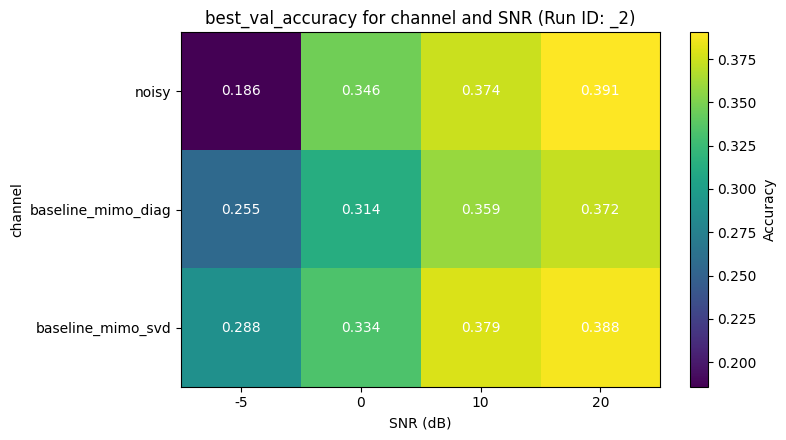

Accuracy clean (best_val_accuracy): 0.375000


In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Specifica l'ID della run da caricare (es. "", "_1", "_2", etc.)
# Se lasci "", cercherà le cartelle base (es. comm=noisy)
run_id = "_2" 
# ---------------------

# Trova la cartella risultati sia se il notebook e lanciato da root sia da Documents
candidate_roots = [
    Path("results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
    Path("../results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
]

root = None
for cand in candidate_roots:
    if cand.exists():
        root = cand
        break

if root is None:
    raise FileNotFoundError("Radice dei risultati non trovata nelle locazioni candidate.")

accuracy_by_channel = {}
clean_acc = None

# Canali previsti nell'ordine di visualizzazione
desired_order = ["noisy", "baseline_mimo_diag", "baseline_mimo_svd"]

# 1. Gestione speciale per CLEAN (Fallback su 'clean' se 'clean{run_id}' non esiste)
clean_folder_name = f"comm=clean{run_id}"
clean_path = root / clean_folder_name
if not clean_path.exists():
    # Fallback su cartella clean base
    clean_path = root / "comm=clean"

if clean_path.exists():
    json_path = clean_path / "best_training_results.json"
    if json_path.exists():
        data = json.loads(json_path.read_text(encoding="utf-8"))
        best_val = data.get("best_val_accuracy")
        clean_acc = float(best_val) if best_val is not None else None
    else:
        print(f"Warning: File non trovato in {clean_path}")

# 2. Caricamento altri canali (Errore se non presenti)
for base_name in desired_order:
    folder_name = f"comm={base_name}{run_id}"
    channel_path = root / folder_name
    
    if not channel_path.exists():
        raise FileNotFoundError(f"Errore: la cartella richiesta '{folder_name}' non è stata trovata in {root}")
    
    json_path = channel_path / "best_training_results.json"
    if not json_path.exists():
        raise FileNotFoundError(f"Errore: file 'best_training_results.json' mancante in {channel_path}")

    data = json.loads(json_path.read_text(encoding="utf-8"))
    best_val_accuracy = data.get("best_val_accuracy")

    if best_val_accuracy is not None:
        # Filtro SNR=5.0 come nel codice originale
        filtered = {
            float(k): float(v)
            for k, v in best_val_accuracy.items()
            if float(k) != 5.0
        }
        accuracy_by_channel[base_name] = filtered

# Costruisci matrice heatmap
channels_present = [c for c in desired_order if c in accuracy_by_channel]
snrs = sorted({snr for ch in channels_present for snr in accuracy_by_channel[ch].keys()})
matrix = [[accuracy_by_channel[ch].get(snr, float("nan")) for snr in snrs] for ch in channels_present]

# Plotting
fig, ax = plt.subplots(figsize=(8, 3 + 0.5 * len(channels_present)))
im = ax.imshow(matrix, aspect="auto")
fig.colorbar(im, ax=ax, label="Accuracy")

ax.set_xticks(range(len(snrs)))
ax.set_xticklabels([f"{s:g}" for s in snrs])
ax.set_yticks(range(len(channels_present)))
ax.set_yticklabels(channels_present)
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("channel")
ax.set_title(f"best_val_accuracy for channel and SNR (Run ID: {run_id if run_id else 'default'})")

for i in range(len(channels_present)):
    for j in range(len(snrs)):
        v = matrix[i][j]
        if v == v: # Check for NaN
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", color="white")

plt.tight_layout()
plt.show()

if clean_acc is not None:
    print(f"Accuracy clean (best_val_accuracy): {clean_acc:.6f}")


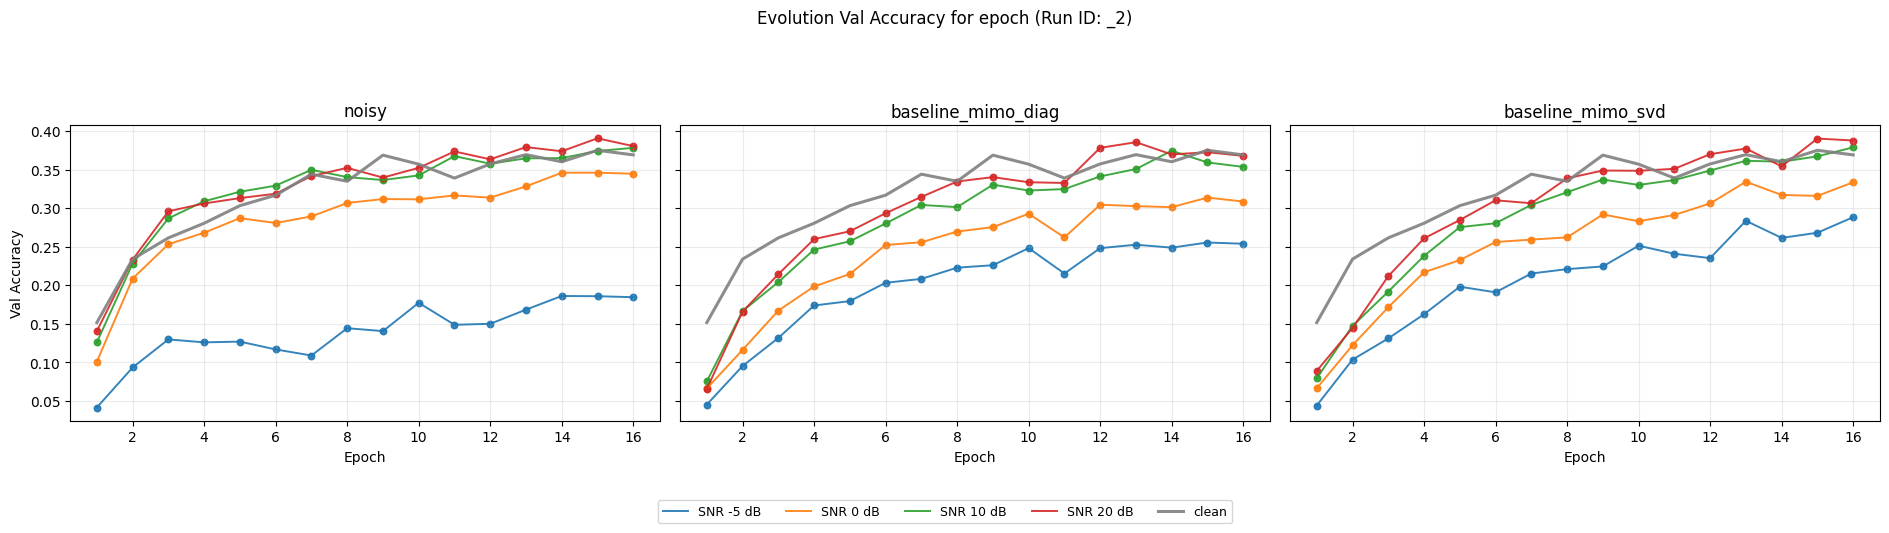

In [3]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Specifica l'ID della run da caricare (es. "", "_1", "_2", etc.)
run_id = "_2" 
# ---------------------

# Trova la cartella proposal in modo robusto
candidate_proposal_roots = [
    Path("results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
    Path("../results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
]

proposal_root = None
for cand in candidate_proposal_roots:
    if cand.exists():
        proposal_root = cand
        break

if proposal_root is None:
    raise FileNotFoundError("Radice dei risultati 'proposal' non trovata.")

channels = ["noisy", "baseline_mimo_diag", "baseline_mimo_svd"]
channel_to_val_acc = {}

# 1. Caricamento canali (Errore se la cartella specifica run_id non esiste)
for channel in channels:
    folder_name = f"comm={channel}{run_id}"
    channel_path = proposal_root / folder_name
    
    if not channel_path.exists():
        raise FileNotFoundError(f"Errore: la cartella richiesta '{folder_name}' non è stata trovata in {proposal_root}")
        
    fp = channel_path / "final_training_results.json"
    if not fp.exists():
        raise FileNotFoundError(f"Errore: file 'final_training_results.json' mancante in {channel_path}")

    data = json.loads(fp.read_text(encoding="utf-8"))
    val_acc = data.get("Val accuracies")
    channel_to_val_acc[channel] = val_acc

# 2. Caricamento CLEAN (Fallback su 'clean' se 'clean{run_id}' manca)
clean_folder_name = f"comm=clean{run_id}"
clean_path = proposal_root / clean_folder_name
if not clean_path.exists():
    clean_path = proposal_root / "comm=clean"

if not clean_path.exists():
    raise FileNotFoundError(f"Errore: neanche la cartella clean base è stata trovata in {proposal_root}")

clean_fp = clean_path / "final_training_results.json"
if not clean_fp.exists():
    raise FileNotFoundError(f"Errore: file 'final_training_results.json' non trovato in {clean_path}")

clean_data = json.loads(clean_fp.read_text(encoding="utf-8"))
clean_val_acc = clean_data.get("Val accuracies")
clean_series = [float(v) for v in clean_val_acc]

# --- PLOTTING ---
fig, axes = plt.subplots(1, 3, figsize=(19, 5), sharey=True)

for ax, channel in zip(axes, channels):
    val_acc = channel_to_val_acc[channel]
    epochs = list(range(1, len(val_acc) + 1))

    # Estrai livelli SNR dai dati caricati
    snr_levels = sorted({float(snr) for epoch_dict in val_acc for snr in epoch_dict.keys()})

    for snr in snr_levels:
        key = str(int(snr)) if snr.is_integer() else str(snr)
        y = [float(epoch_dict.get(key, float("nan"))) for epoch_dict in val_acc]

        ax.scatter(epochs, y, s=22, alpha=0.9)
        ax.plot(epochs, y, linewidth=1.4, alpha=0.9, label=f"SNR {snr:g} dB")

    # Aggiunta serie clean
    n = min(len(epochs), len(clean_series))
    ax.plot(
        epochs[:n],
        clean_series[:n],
        color="gray",
        linewidth=2.2,
        linestyle="-",
        alpha=0.9,
        label="clean",
    )

    ax.set_title(f"{channel}")
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)

# Legenda unica condivisa
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))

axes[0].set_ylabel("Val Accuracy")
fig.suptitle(f"Evolution Val Accuracy for epoch (Run ID: {run_id if run_id else 'default'})", y=1.02)
plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()


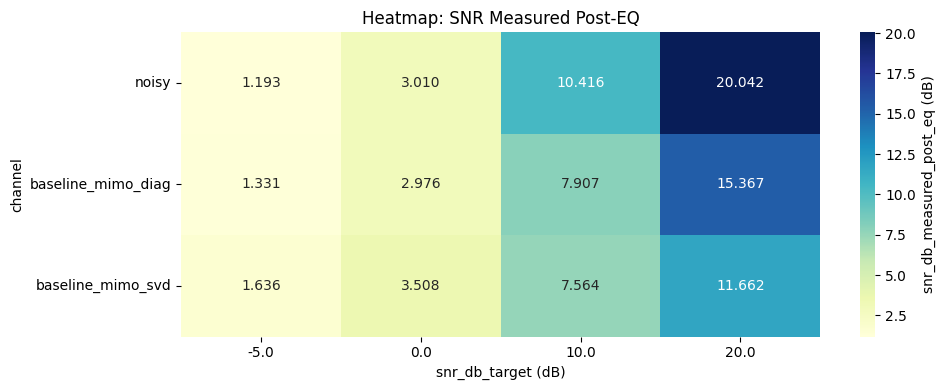

In [5]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- CONFIGURATION ---
# Specifica l'ID della run da caricare (es. "", "_1", "_2", etc.)
run_id = "_2" 
# ---------------------

# Trova la cartella proposal in modo robusto
candidate_proposal_roots = [
    Path("results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
    Path("../results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
]

proposal_root = None
for cand in candidate_proposal_roots:
    if cand.exists():
        proposal_root = cand
        break

if proposal_root is None:
    raise FileNotFoundError("Radice dei risultati 'proposal' non trovata.")

channels = ["noisy", "baseline_mimo_diag", "baseline_mimo_svd"]
rows = []
pattern = re.compile(r"^best_val_snr_db_measured_post_eq_snr_(.+)$")

# Caricamento canali (Errore se la cartella specifica run_id non esiste)
for channel in channels:
    folder_name = f"comm={channel}{run_id}"
    channel_path = proposal_root / folder_name
    
    if not channel_path.exists():
        raise FileNotFoundError(f"Errore: la cartella richiesta '{folder_name}' non è stata trovata in {proposal_root}")
        
    fp = channel_path / "best_training_results.json"
    if not fp.exists():
        raise FileNotFoundError(f"Errore: file 'best_training_results.json' mancante in {channel_path}")

    data = json.loads(fp.read_text(encoding="utf-8"))

    # Estrazione dati tramite regex
    for key, measured_post_eq in data.items():
        match = pattern.match(key)
        if not match:
            continue

        snr_suffix = match.group(1)
        target_key = f"best_val_snr_db_target_snr_{snr_suffix}"
        snr_target = data.get(target_key)

        if snr_target is None:
            continue

        rows.append(
            {
                "channel": channel,
                "snr_db_target": float(snr_target),
                "snr_db_measured_post_eq": float(measured_post_eq),
            }
        )

# Elaborazione DataFrame
plot_df = pd.DataFrame(rows)

if plot_df.empty:
    print(f"Nessun dato trovato per run_id: {run_id}")
else:
    plot_df = plot_df[plot_df["snr_db_target"] != 5.0]
    plot_df = plot_df.sort_values(["channel", "snr_db_target"]).reset_index(drop=True)

    # Heatmap: assi = canale e snr target, celle = snr measured post-eq
    pivot = plot_df.pivot(index="channel", columns="snr_db_target", values="snr_db_measured_post_eq")
    pivot = pivot.reindex(channels)
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)

    # Visualizzazione
    plt.figure(figsize=(10, 4))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        cbar_kws={"label": "snr_db_measured_post_eq (dB)"},
    )

    plt.title(f"Heatmap: SNR Measured Post-EQ")
    plt.xlabel("snr_db_target (dB)")
    plt.ylabel("channel")
    plt.tight_layout()
    plt.show()


### svd experiment

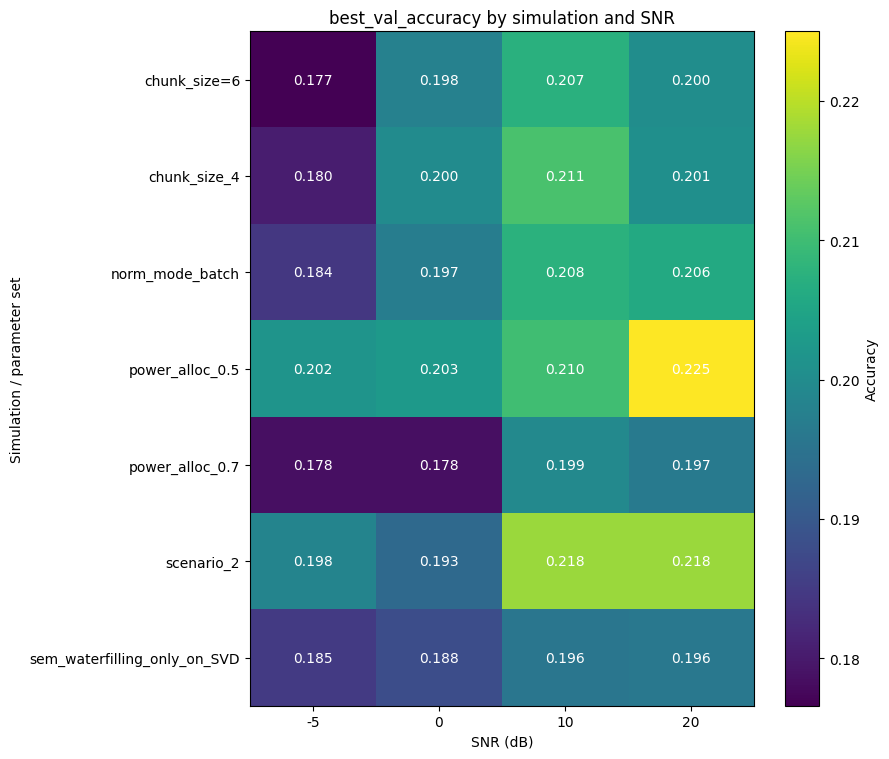

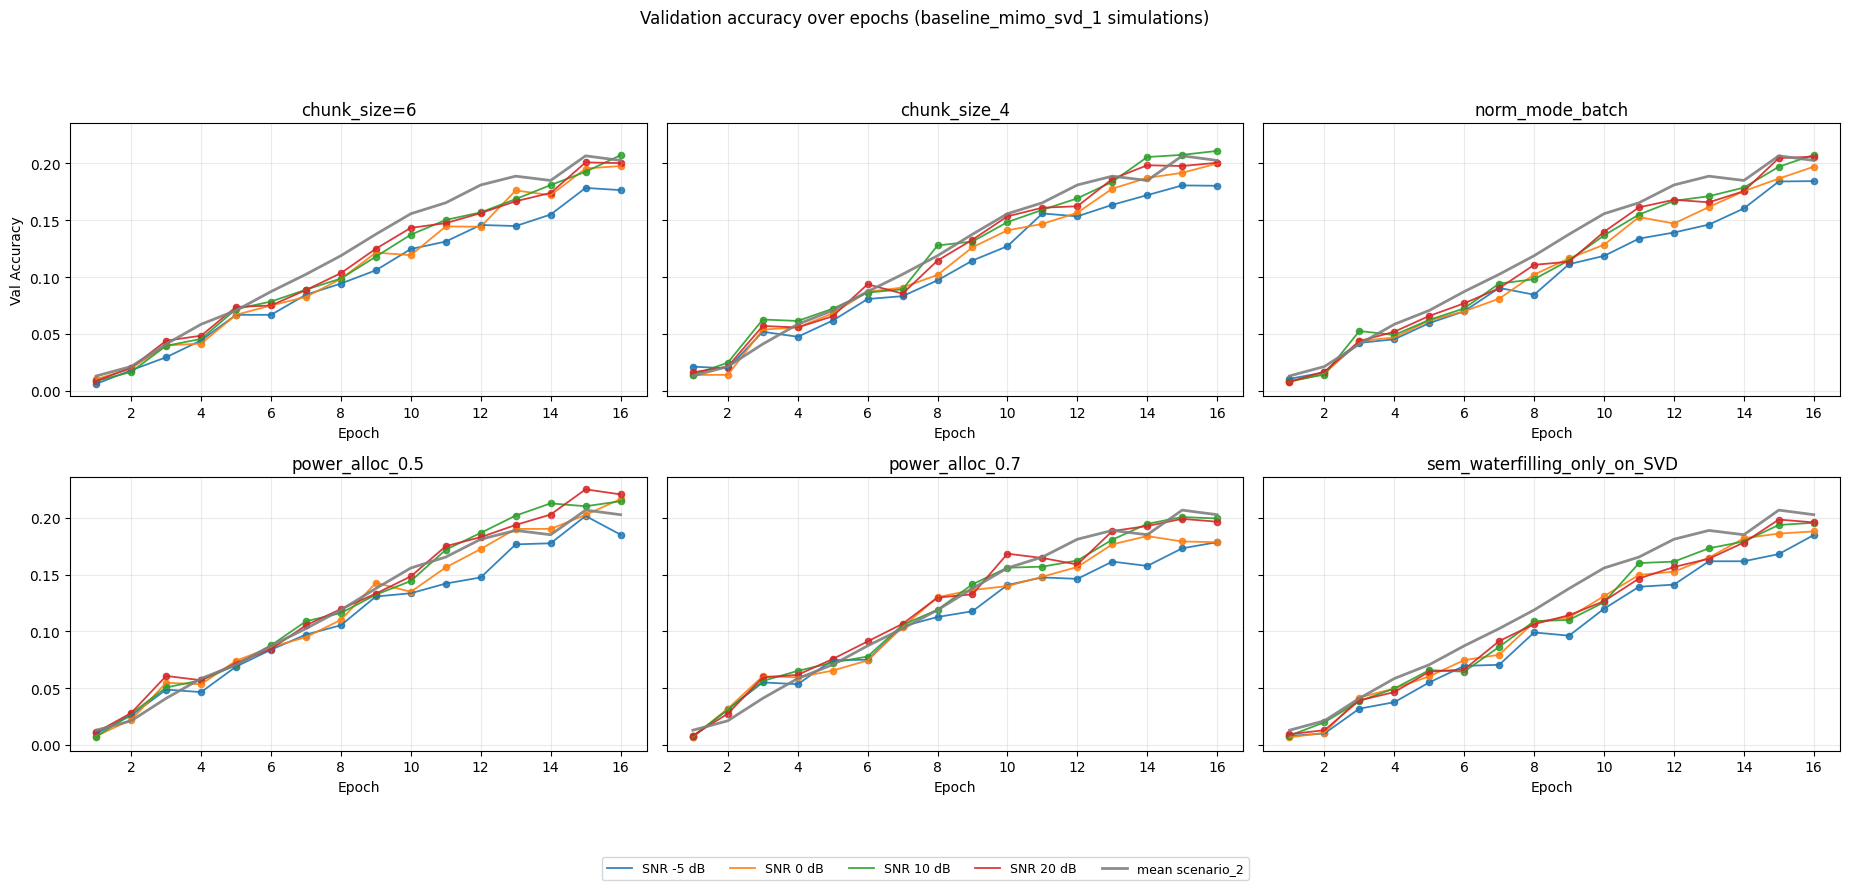

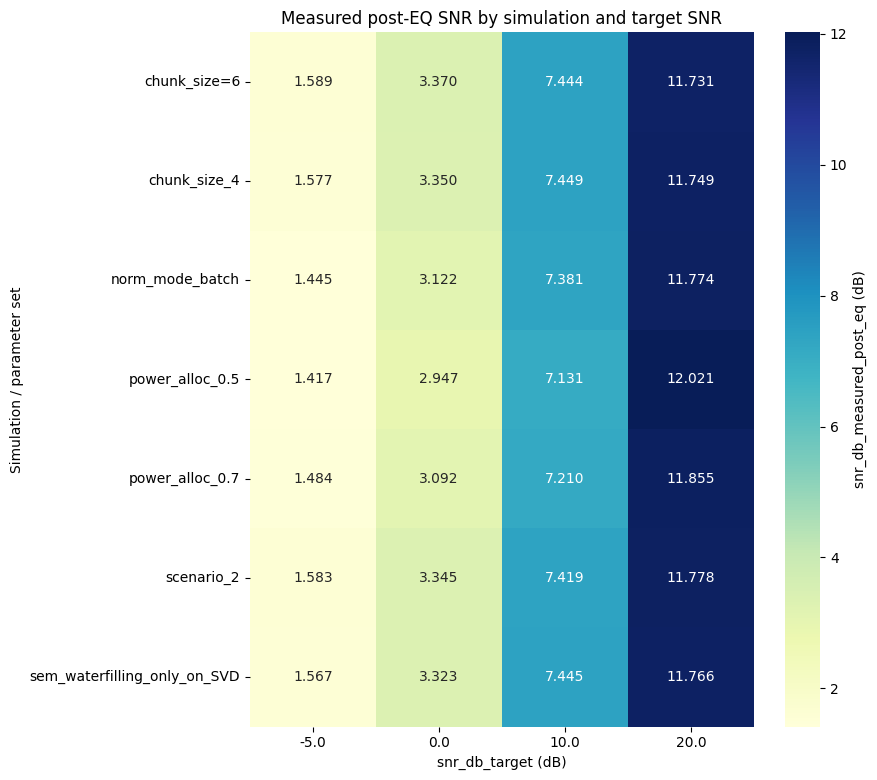

In [1]:
import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- CONFIGURATION ---
# You can exclude specific SNR values from plotting.
snr_to_exclude = {5.0}
scenario2_name = "scenario_2"

# Root folder for variable-parameter simulation runs
candidate_variant_roots = [
    Path("/results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal/comm=baseline_mimo_svd_exp"),
    Path("../results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal/comm=baseline_mimo_svd_exp"),
]

variant_root = None
for cand in candidate_variant_roots:
    if cand.exists():
        variant_root = cand
        break

if variant_root is None:
    raise FileNotFoundError("Root folder 'comm=baseline_mimo_svd_exp' not found in candidate locations.")

# Scan simulations: include each subfolder that contains both required JSON files
simulation_dirs = []
skipped_dirs = []
for child in sorted(variant_root.iterdir()):
    if not child.is_dir():
        continue
    best_fp = child / "best_training_results.json"
    final_fp = child / "final_training_results.json"
    if best_fp.exists() and final_fp.exists():
        simulation_dirs.append(child)
    else:
        skipped_dirs.append(child.name)

if not simulation_dirs:
    raise FileNotFoundError(
        f"No valid simulation found in {variant_root}. "
        "Expected both 'best_training_results.json' and 'final_training_results.json' in at least one subfolder."
    )

if skipped_dirs:
    print("Skipped folders (missing JSON files):", ", ".join(skipped_dirs))

sim_labels = [d.name for d in simulation_dirs]

# =====================================================================
# PLOT 1: best_val_accuracy heatmap (rows=simulations, columns=SNR)
# =====================================================================
best_acc_by_sim = {}
for sim_dir in simulation_dirs:
    data = json.loads((sim_dir / "best_training_results.json").read_text(encoding="utf-8"))
    best_val_accuracy = data.get("best_val_accuracy")
    if isinstance(best_val_accuracy, dict):
        filtered = {
            float(k): float(v)
            for k, v in best_val_accuracy.items()
            if float(k) not in snr_to_exclude
        }
        if filtered:
            best_acc_by_sim[sim_dir.name] = filtered

if not best_acc_by_sim:
    print("[Plot 1] No valid 'best_val_accuracy' values found.")
else:
    sim_present = [s for s in sim_labels if s in best_acc_by_sim]
    snrs = sorted({snr for s in sim_present for snr in best_acc_by_sim[s].keys()})
    matrix = [[best_acc_by_sim[s].get(snr, float("nan")) for snr in snrs] for s in sim_present]

    fig, ax = plt.subplots(figsize=(9, 2.8 + 0.7 * len(sim_present)))
    im = ax.imshow(matrix, aspect="auto")
    fig.colorbar(im, ax=ax, label="Accuracy")

    ax.set_xticks(range(len(snrs)))
    ax.set_xticklabels([f"{s:g}" for s in snrs])
    ax.set_yticks(range(len(sim_present)))
    ax.set_yticklabels(sim_present)
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("Simulation / parameter set")
    ax.set_title("best_val_accuracy by simulation and SNR")

    for i in range(len(sim_present)):
        for j in range(len(snrs)):
            val = matrix[i][j]
            if val == val:  # NaN check
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", color="white")

    plt.tight_layout()
    plt.show()

# =====================================================================
# PLOT 2: Validation accuracy by epoch (one subplot per simulation)
# gray line = epoch-wise mean of values from scenario_2
# =====================================================================
sim_to_val_acc = {}
scenario2_mean_series = None

for sim_dir in simulation_dirs:
    final_data = json.loads((sim_dir / "final_training_results.json").read_text(encoding="utf-8"))
    val_acc = final_data.get("Val accuracies")
    if isinstance(val_acc, list) and len(val_acc) > 0:
        if sim_dir.name == scenario2_name:
            epoch_means = []
            for epoch_dict in val_acc:
                epoch_values = [
                    float(v)
                    for snr_key, v in epoch_dict.items()
                    if float(snr_key) not in snr_to_exclude
                ]
                epoch_means.append(
                    sum(epoch_values) / len(epoch_values) if epoch_values else float("nan")
                )
            if any(v == v for v in epoch_means):
                scenario2_mean_series = epoch_means
            continue

        sim_to_val_acc[sim_dir.name] = val_acc

if scenario2_mean_series is None:
    print(f"[Plot 2] '{scenario2_name}' not found or without valid values: no gray mean line will be shown.")

if not sim_to_val_acc:
    print("[Plot 2] No valid 'Val accuracies' values found.")
else:
    sim_present = [s for s in sim_labels if s in sim_to_val_acc]
    n_sim = len(sim_present)
    n_cols = min(3, n_sim)
    n_rows = math.ceil(n_sim / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6.2 * n_cols, 4.3 * n_rows),
        sharey=True,
    )
    if hasattr(axes, "ravel"):
        axes = list(axes.ravel())
    else:
        axes = [axes]

    for ax, sim_name in zip(axes, sim_present):
        val_acc = sim_to_val_acc[sim_name]
        epochs = list(range(1, len(val_acc) + 1))

        snr_levels = sorted(
            {
                float(snr)
                for epoch_dict in val_acc
                for snr in epoch_dict.keys()
                if float(snr) not in snr_to_exclude
            }
        )

        for snr in snr_levels:
            key = str(int(snr)) if snr.is_integer() else str(snr)
            y = [float(epoch_dict.get(key, float("nan"))) for epoch_dict in val_acc]
            ax.scatter(epochs, y, s=20, alpha=0.85)
            ax.plot(epochs, y, linewidth=1.3, alpha=0.9, label=f"SNR {snr:g} dB")

        if scenario2_mean_series is not None:
            n = min(len(epochs), len(scenario2_mean_series))
            ax.plot(
                epochs[:n],
                scenario2_mean_series[:n],
                color="gray",
                linewidth=2.0,
                linestyle="-",
                alpha=0.9,
                label=f"mean {scenario2_name}",
            )

        ax.set_title(sim_name)
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.25)

    # Hide unused axes if the grid is not full
    for ax in axes[n_sim:]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=min(6, len(labels)),
            fontsize=9,
            frameon=True,
            bbox_to_anchor=(0.5, -0.01),
        )

    axes[0].set_ylabel("Val Accuracy")
    fig.suptitle("Validation accuracy over epochs (baseline_mimo_svd_1 simulations)", y=1.01)
    plt.tight_layout(rect=[0, 0.08, 1, 0.96])
    plt.show()

# =====================================================================
# PLOT 3: post-EQ measured SNR heatmap (rows=simulations, columns=target)
# =====================================================================
rows = []
pattern = re.compile(r"^best_val_snr_db_measured_post_eq_snr_(.+)$")

for sim_dir in simulation_dirs:
    data = json.loads((sim_dir / "best_training_results.json").read_text(encoding="utf-8"))

    for key, measured_post_eq in data.items():
        match = pattern.match(key)
        if not match:
            continue

        snr_suffix = match.group(1)
        target_key = f"best_val_snr_db_target_snr_{snr_suffix}"
        snr_target = data.get(target_key)

        if snr_target is None:
            continue

        snr_target_f = float(snr_target)
        if snr_target_f in snr_to_exclude:
            continue

        rows.append(
            {
                "simulation": sim_dir.name,
                "snr_db_target": snr_target_f,
                "snr_db_measured_post_eq": float(measured_post_eq),
            }
        )

plot_df = pd.DataFrame(rows)
if plot_df.empty:
    print("[Plot 3] No post-EQ SNR data found.")
else:
    pivot = plot_df.pivot(
        index="simulation",
        columns="snr_db_target",
        values="snr_db_measured_post_eq",
    )
    pivot = pivot.reindex(sim_labels)
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)

    plt.figure(figsize=(9, 3.0 + 0.7 * len(sim_labels)))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        cbar_kws={"label": "snr_db_measured_post_eq (dB)"},
    )
    plt.title("Measured post-EQ SNR by simulation and target SNR")
    plt.xlabel("snr_db_target (dB)")
    plt.ylabel("Simulation / parameter set")
    plt.tight_layout()
    plt.show()

### clean comparison

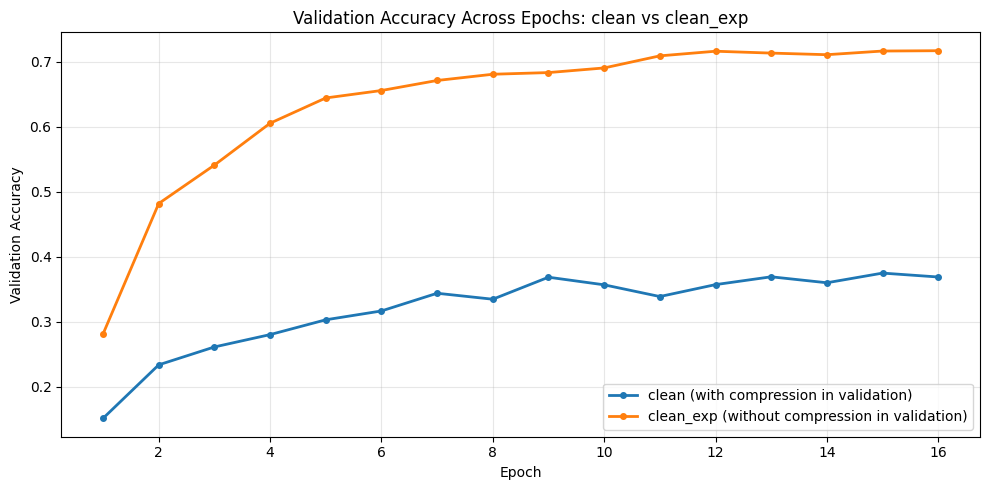

In [7]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Compare only clean and clean_exp on validation accuracy across epochs.
candidate_proposal_roots = [
    Path("results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
    Path("../results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
]

proposal_root = None
for cand in candidate_proposal_roots:
    if cand.exists():
        proposal_root = cand
        break

if proposal_root is None:
    raise FileNotFoundError("Proposal root folder not found in candidate locations.")


def to_epoch_series(raw_vals):
    """Convert Val accuracies to a numeric epoch-wise series."""
    series = []
    for item in raw_vals:
        if isinstance(item, dict):
            vals = [float(v) for v in item.values()]
            series.append(sum(vals) / len(vals) if vals else float("nan"))
        else:
            series.append(float(item))
    return series


case_configs = [
    {
        "folder": "comm=clean",
        "label": "clean (with compression in validation)",
        "color": "tab:blue",
    },
    {
        "folder": "comm=clean_exp",
        "label": "clean_exp (without compression in validation)",
        "color": "tab:orange",
    },
]

series_by_case = {}
for cfg in case_configs:
    fp = proposal_root / cfg["folder"] / "final_training_results.json"
    if not fp.exists():
        raise FileNotFoundError(f"Missing file: {fp}")

    data = json.loads(fp.read_text(encoding="utf-8"))
    val_acc = data.get("Val accuracies")
    if not isinstance(val_acc, list) or len(val_acc) == 0:
        raise ValueError(f"Invalid or empty 'Val accuracies' in {fp}")

    series_by_case[cfg["label"]] = {
        "values": to_epoch_series(val_acc),
        "color": cfg["color"],
    }

max_epochs = max(len(v["values"]) for v in series_by_case.values())
epochs = list(range(1, max_epochs + 1))

plt.figure(figsize=(10, 5))
for label, payload in series_by_case.items():
    y = payload["values"]
    x = epochs[: len(y)]
    plt.plot(x, y, marker="o", linewidth=2.0, markersize=4, label=label, color=payload["color"])

plt.title("Validation Accuracy Across Epochs: clean vs clean_exp")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### baseline comparison

Using results root: C:\Users\matteo\OneDrive - uniroma1.it\Documenti\data science\Tesi\proj_locale\results


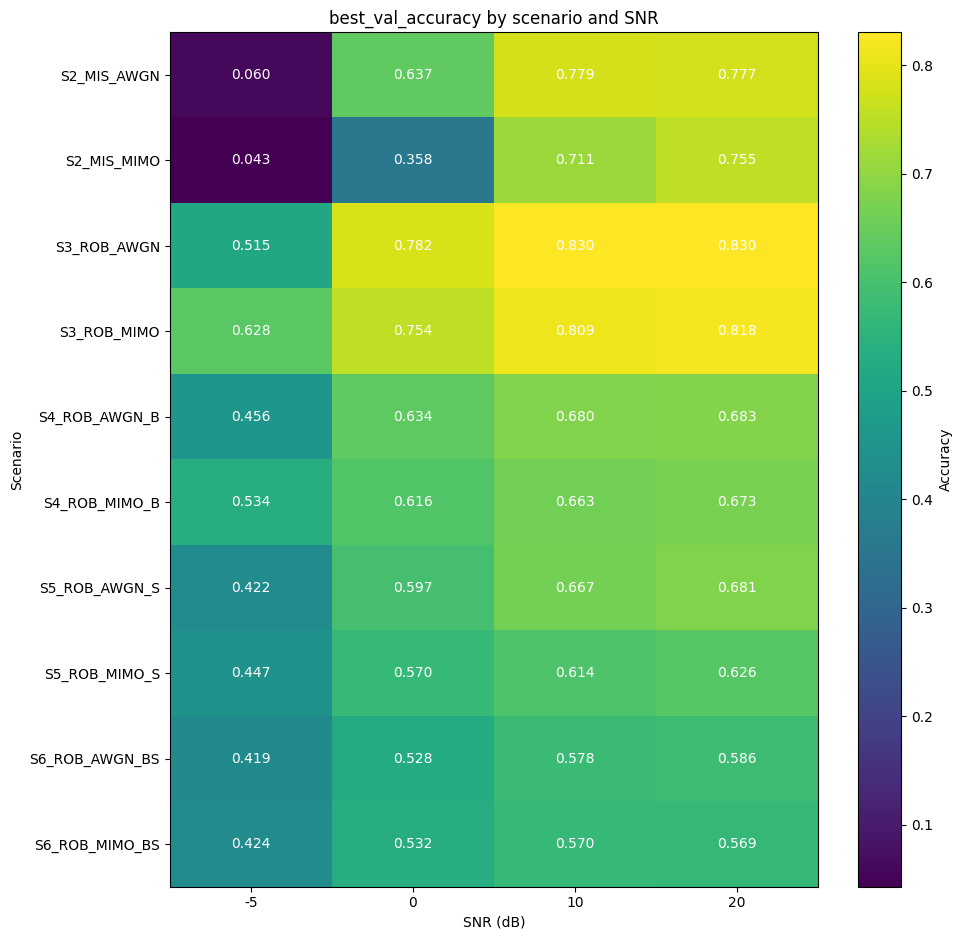

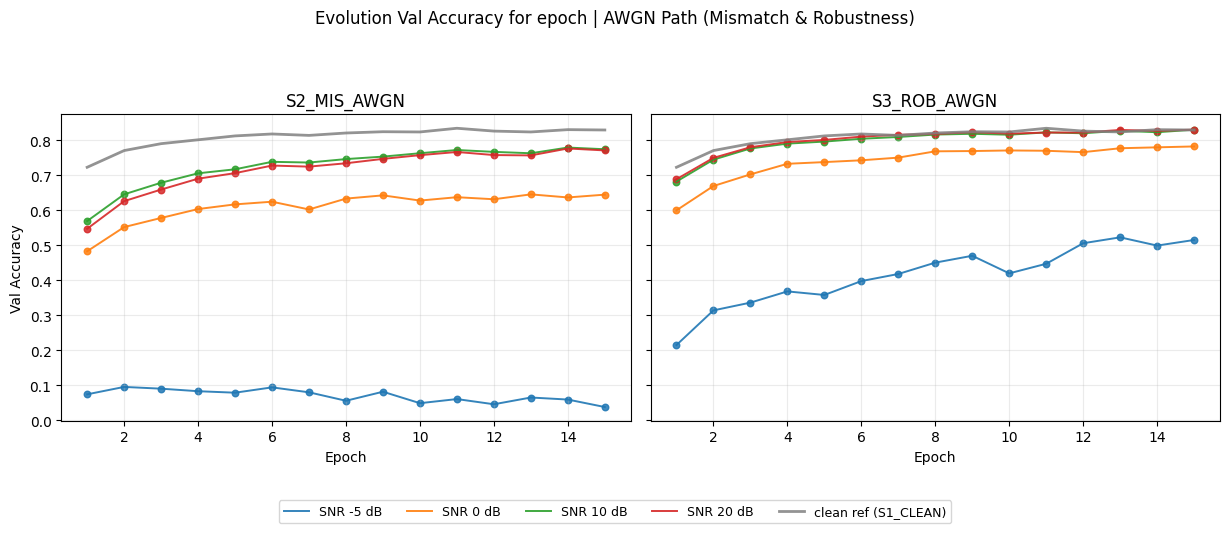

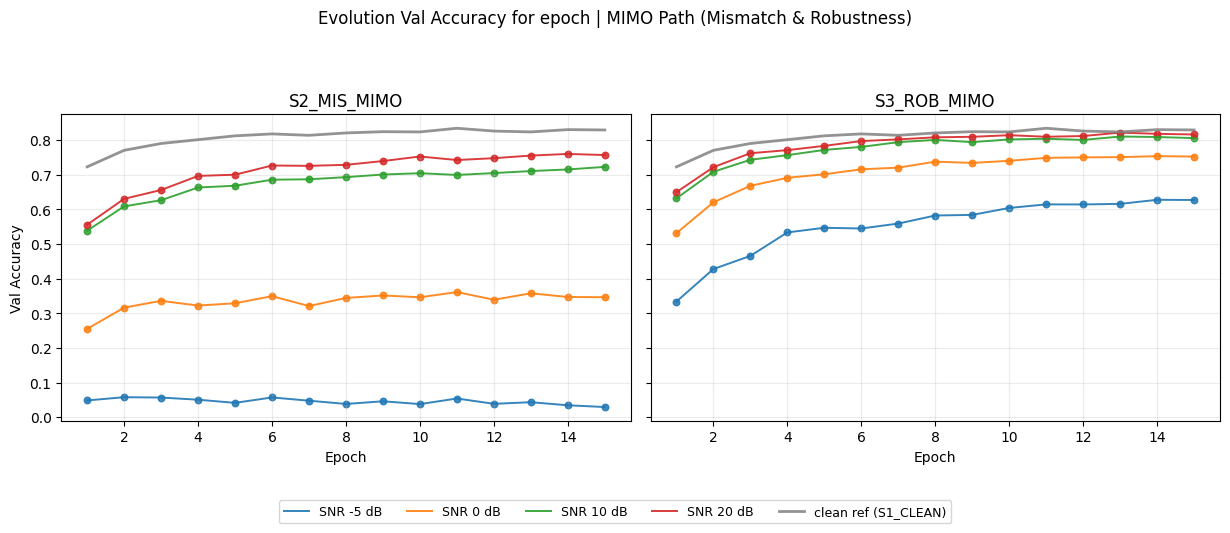

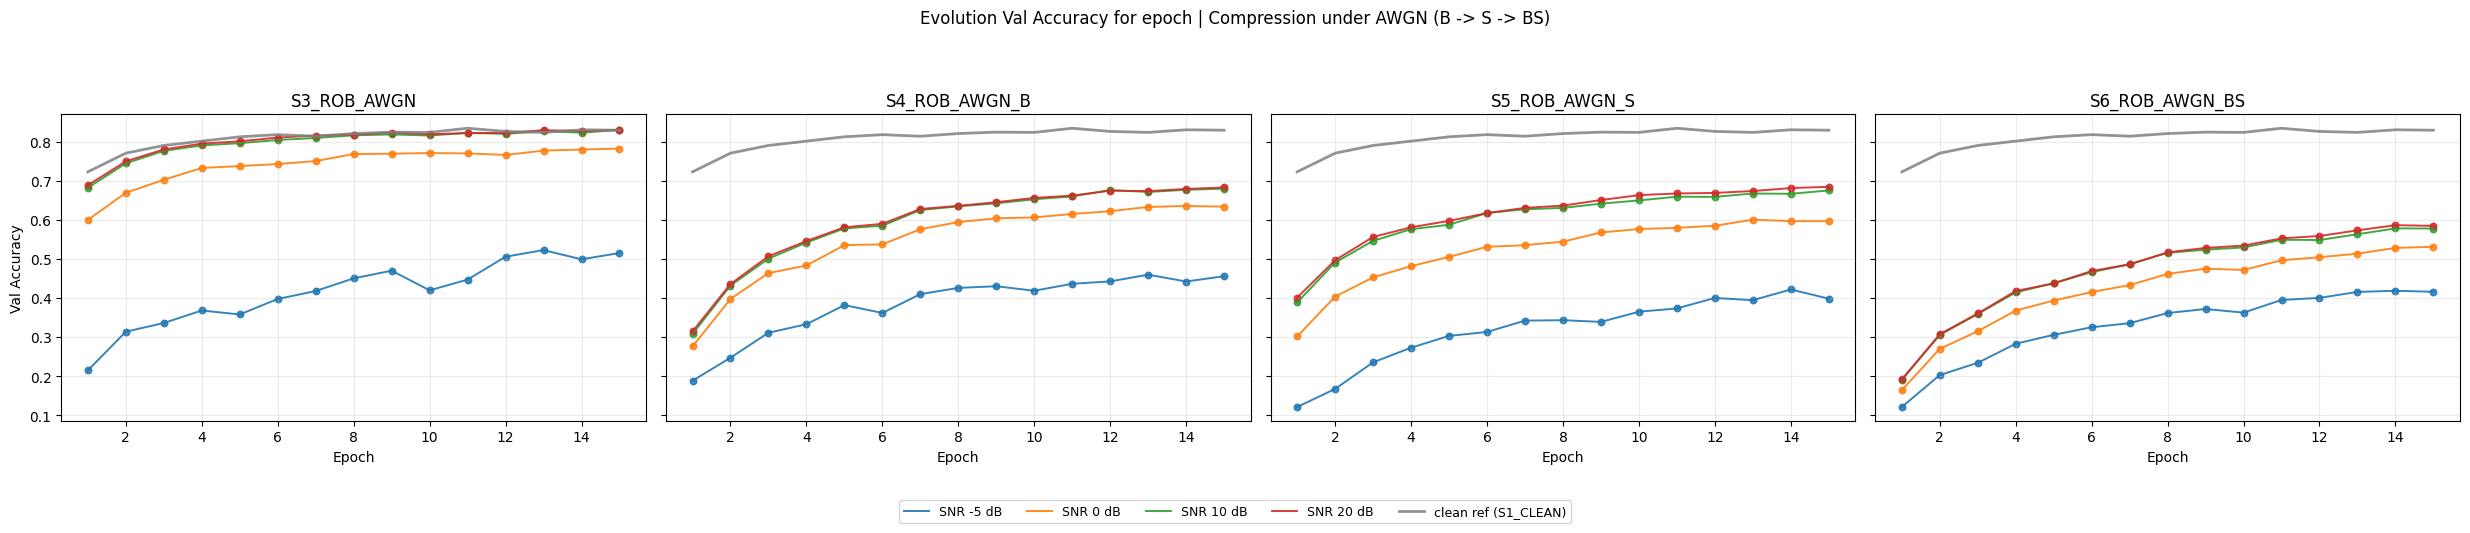

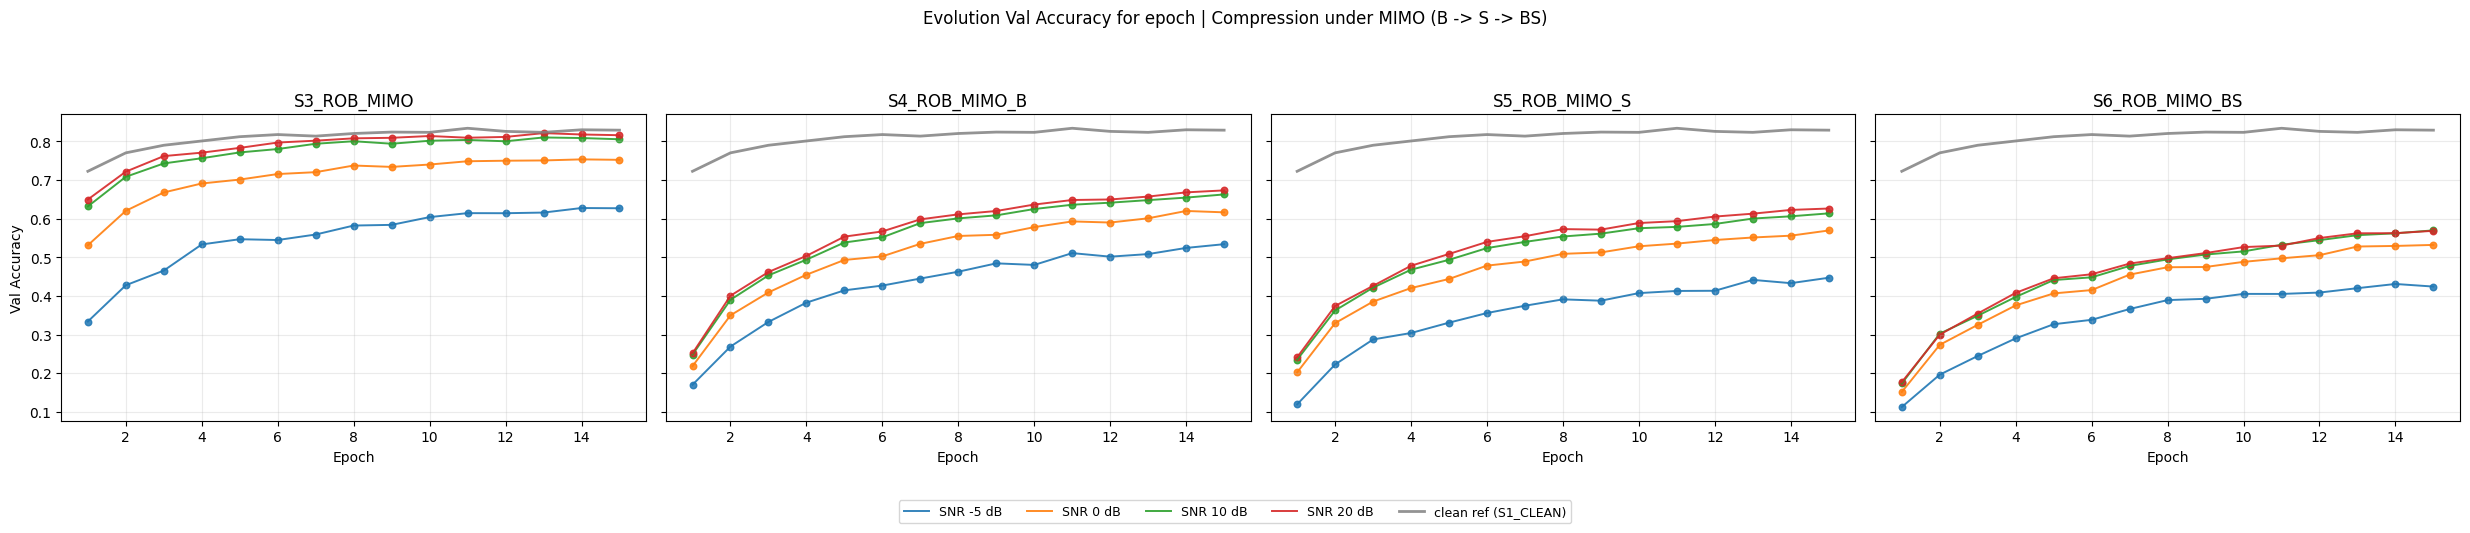

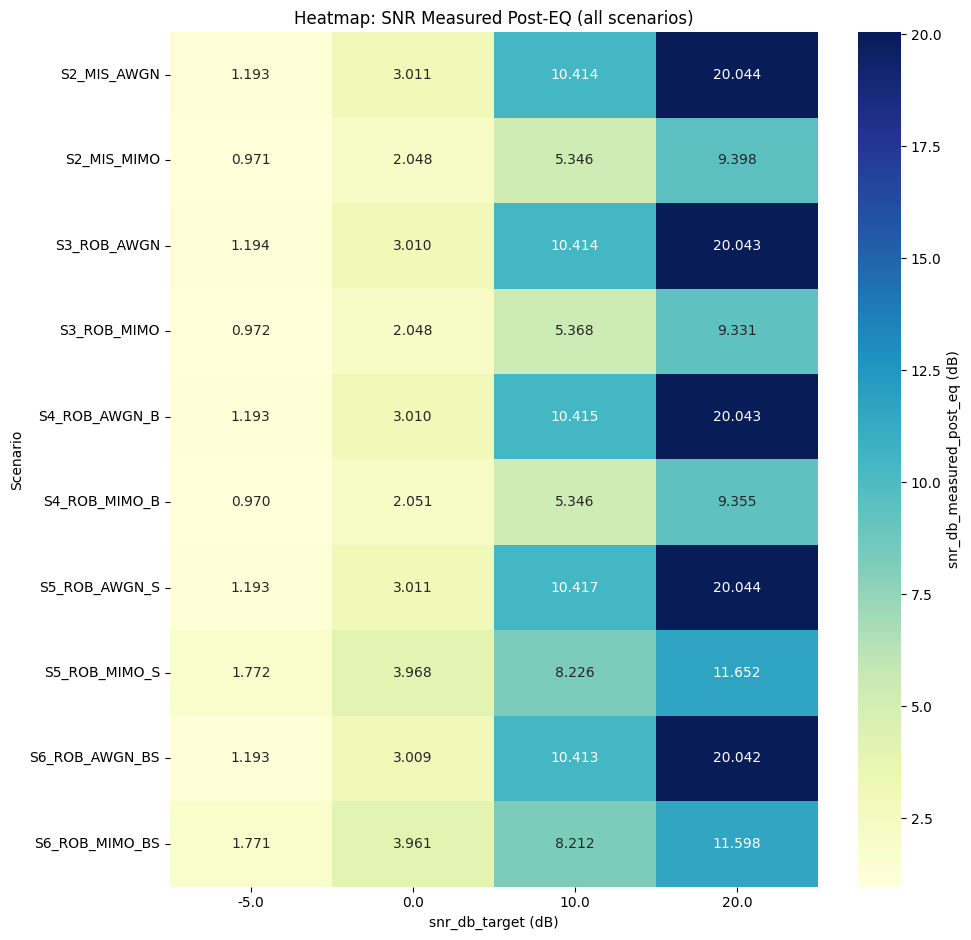


Loaded scenarios:
- S1_CLEAN: S1_CLEAN (flat)
- S2_MIS_AWGN: S2_MIS_AWGN (flat)
- S2_MIS_MIMO: S2_MIS_MIMO (flat)
- S3_ROB_AWGN: S3_ROB_AWGN (flat)
- S3_ROB_MIMO: S3_ROB_MIMO (flat)
- S4_ROB_AWGN_B: S4_ROB_AWGN_B (flat)
- S4_ROB_MIMO_B: S4_ROB_MIMO_B (flat)
- S5_ROB_AWGN_S: S5_ROB_AWGN_S (flat)
- S5_ROB_MIMO_S: S5_ROB_MIMO_S (flat)
- S6_ROB_AWGN_BS: S6_ROB_AWGN_BS (flat)
- S6_ROB_MIMO_BS: S6_ROB_MIMO_BS (flat)


In [2]:
import json
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# =====================================================================
# Baseline comparison with consolidated viewing:
# 1) ONE best_val_accuracy heatmap with all scenarios
# 2) Evolution plots by path, with S1_CLEAN gray reference in each subplot
# 3) ONE post-EQ measured SNR heatmap with all scenarios
# =====================================================================

run_id = ""  # e.g. "", "_1", "_2"
snr_to_exclude = {5.0}

SCENARIOS = {
    "S1_CLEAN": {
        "experiments": ["S1_CLEAN"],
        "method": "base",
        "comm": "clean",
    },
    "S2_MIS_AWGN": {
        "experiments": ["S2_MIS_AWGN"],
        "method": "gumbel_eval_channel",
        "comm": "baseline_mimo",
    },
    "S2_MIS_MIMO": {
        "experiments": ["S2_MIS_MIMO"],
        "method": "gumbel_eval_channel",
        "comm": "baseline_mimo_svd",
    },
    "S3_ROB_AWGN": {
        "experiments": ["S3_ROB_AWGN"],
        "method": "base",
        "comm": "baseline_mimo",
    },
    "S3_ROB_MIMO": {
        "experiments": ["S3_ROB_MIMO"],
        "method": "base",
        "comm": "baseline_mimo_svd",
    },
    "S4_ROB_AWGN_B": {
        "experiments": ["S4_ROB_AWGN_B"],
        "method": "base",
        "comm": "baseline_mimo",
    },
    "S4_ROB_MIMO_B": {
        "experiments": ["S4_ROB_MIMO_B"],
        "method": "base",
        "comm": "baseline_mimo_svd",
    },
    "S5_ROB_AWGN_S": {
        "experiments": ["S5_ROB_AWGN_S"],
        "method": "gumbel_eval_channel",
        "comm": "baseline_mimo",
    },
    "S5_ROB_MIMO_S": {
        "experiments": ["S5_ROB_MIMO_S"],
        "method": "gumbel_eval_channel",
        "comm": "baseline_mimo_svd",
    },
    "S6_ROB_AWGN_BS": {
        "experiments": ["S6_ROB_AWGN_BS"],
        "method": "gumbel_eval_channel",
        "comm": "baseline_mimo",
    },
    "S6_ROB_MIMO_BS": {
        "experiments": ["S6_ROB_MIMO_BS"],
        "method": "gumbel_eval_channel",
        "comm": "baseline_mimo_svd",
    },
}

# Grouping for evolution plots: each subplot also includes S1 como gray reference
EVOLUTION_GROUPS = [
    ("AWGN Path (Mismatch & Robustness)", ["S2_MIS_AWGN", "S3_ROB_AWGN"]),
    ("MIMO Path (Mismatch & Robustness)", ["S2_MIS_MIMO", "S3_ROB_MIMO"]),
    ("Compression under AWGN (B -> S -> BS)", ["S3_ROB_AWGN", "S4_ROB_AWGN_B", "S5_ROB_AWGN_S", "S6_ROB_AWGN_BS"]),
    ("Compression under MIMO (B -> S -> BS)", ["S3_ROB_MIMO", "S4_ROB_MIMO_B", "S5_ROB_MIMO_S", "S6_ROB_MIMO_BS"]),
]

candidate_results_roots = [Path("results"), Path("../results"), Path("../../results")]


def _find_existing_results_root() -> Path:
    for cand in candidate_results_roots:
        if cand.exists():
            return cand
    raise FileNotFoundError("Results root non trovato nelle locazioni candidate.")


def _load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"File non trovato: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


def _extract_best_val_by_snr(best_data: dict) -> dict:
    best = best_data.get("best_val_accuracy")
    if not isinstance(best, dict):
        return {}
    out = {}
    for k, v in best.items():
        snr = float(k)
        if snr in snr_to_exclude:
            continue
        out[snr] = float(v)
    return out


def _extract_epoch_payload(final_data: dict):
    vals = final_data.get("Val accuracies")
    if not isinstance(vals, list) or len(vals) == 0:
        raise ValueError("Campo 'Val accuracies' assente o vuoto in final_training_results.json")

    # Case 1: list of dicts (per-SNR values at each epoch)
    if all(isinstance(item, dict) for item in vals):
        snr_levels = sorted(
            {
                float(snr)
                for epoch_dict in vals
                for snr in epoch_dict.keys()
                if float(snr) not in snr_to_exclude
            }
        )
        by_snr = {}
        for snr in snr_levels:
            key = str(int(snr)) if snr.is_integer() else str(snr)
            by_snr[snr] = [float(epoch_dict.get(key, float("nan"))) for epoch_dict in vals]

        mean_series = []
        for epoch_dict in vals:
            epoch_vals = [float(v) for k, v in epoch_dict.items() if float(k) not in snr_to_exclude]
            mean_series.append(float(np.mean(epoch_vals)) if epoch_vals else float("nan"))

        return {"by_snr": by_snr, "mean_series": mean_series}

    # Case 2: list of scalars (clean-like)
    mean_series = [float(v) for v in vals]
    return {"by_snr": {}, "mean_series": mean_series}


def _extract_measured_post_eq_by_target(best_data: dict) -> dict:
    rows = {}
    pattern = re.compile(r"^best_val_snr_db_measured_post_eq_snr_(.+)$")
    for key, measured_post_eq in best_data.items():
        match = pattern.match(key)
        if not match:
            continue

        snr_suffix = match.group(1)
        target_key = f"best_val_snr_db_target_snr_{snr_suffix}"
        snr_target = best_data.get(target_key)
        if snr_target is None:
            continue

        snr_target_f = float(snr_target)
        if snr_target_f in snr_to_exclude:
            continue

        rows[snr_target_f] = float(measured_post_eq)
    return rows


def _resolve_run_folder(results_root: Path, cfg: dict, run_id: str):
    tried = []
    for exp_name in cfg["experiments"]:
        scenario_root = results_root / exp_name

        # Flat layout: JSON files directly in scenario folder
        flat_best = scenario_root / "best_training_results.json"
        flat_final = scenario_root / "final_training_results.json"
        tried.append(("flat", scenario_root))
        if flat_best.exists() and flat_final.exists():
            return scenario_root, exp_name, "flat"

        # Nested layout: scenario/dataset/model/method/comm=...
        method_root = scenario_root / "cifar100" / "deit_tiny_patch16_224.fb_in1k" / cfg["method"]
        nested_folder = method_root / f"comm={cfg['comm']}{run_id}"
        nested_best = nested_folder / "best_training_results.json"
        nested_final = nested_folder / "final_training_results.json"
        tried.append(("nested", nested_folder))
        if nested_best.exists() and nested_final.exists():
            return nested_folder, exp_name, "nested"

    tried_str = "\n".join([f"- {layout}: {path}" for layout, path in tried])
    raise FileNotFoundError(
        "Nessun folder risultati valido trovato per scenario. Percorsi controllati:\n"
        f"{tried_str}"
    )


# =====================================================================
# Load scenario data
# =====================================================================
results_root = _find_existing_results_root()
print(f"Using results root: {results_root.resolve()}")

scenario_data = {}
for name, cfg in SCENARIOS.items():
    run_folder, exp_used, layout_used = _resolve_run_folder(results_root, cfg, run_id)
    best_fp = run_folder / "best_training_results.json"
    final_fp = run_folder / "final_training_results.json"

    best_data = _load_json(best_fp)
    final_data = _load_json(final_fp)

    scenario_data[name] = {
        "best_data": best_data,
        "final_data": final_data,
        "best_by_snr": _extract_best_val_by_snr(best_data),
        "epoch_payload": _extract_epoch_payload(final_data),
        "measured_post_eq": _extract_measured_post_eq_by_target(best_data),
        "run_folder": str(run_folder),
        "experiment_used": exp_used,
        "layout_used": layout_used,
    }


# =====================================================================
# Plot 1: ONE best_val_accuracy heatmap with ALL scenarios
# =====================================================================
all_scenarios = list(SCENARIOS.keys())
rows_present = [s for s in all_scenarios if scenario_data[s]["best_by_snr"]]

if rows_present:
    snrs = sorted({snr for s in rows_present for snr in scenario_data[s]["best_by_snr"].keys()})
    matrix = [[scenario_data[s]["best_by_snr"].get(snr, float("nan")) for snr in snrs] for s in rows_present]

    fig, ax = plt.subplots(figsize=(10, 3 + 0.65 * len(rows_present)))
    im = ax.imshow(matrix, aspect="auto")
    fig.colorbar(im, ax=ax, label="Accuracy")

    ax.set_xticks(range(len(snrs)))
    ax.set_xticklabels([f"{s:g}" for s in snrs])
    ax.set_yticks(range(len(rows_present)))
    ax.set_yticklabels(rows_present)
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("Scenario")
    ax.set_title("best_val_accuracy by scenario and SNR")

    for i in range(len(rows_present)):
        for j in range(len(snrs)):
            val = matrix[i][j]
            if val == val:  # NaN check
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", color="white")

    plt.tight_layout()
    plt.show()
else:
    print("[best_val_accuracy heatmap] Nessun dato disponibile.")


# =====================================================================
# Plot 2: Evolution Val Accuracy - subplots with S1_CLEAN gray reference
# =====================================================================
clean_reference = scenario_data["S1_CLEAN"]["epoch_payload"]["mean_series"]

for group_title, scenario_names in EVOLUTION_GROUPS:
    n = len(scenario_names)
    fig, axes = plt.subplots(1, n, figsize=(6.2 * n, 5.0), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, scenario_name in zip(axes, scenario_names):
        payload = scenario_data[scenario_name]["epoch_payload"]
        by_snr = payload["by_snr"]
        mean_series = payload["mean_series"]
        epochs = list(range(1, len(mean_series) + 1))

        # Plot per-SNR data with markers and lines
        if by_snr:
            for snr in sorted(by_snr.keys()):
                y = by_snr[snr]
                ax.scatter(epochs, y, s=22, alpha=0.85)
                ax.plot(epochs, y, linewidth=1.4, alpha=0.9, label=f"SNR {snr:g} dB")
        else:
            # Clean-like: just the mean line
            ax.plot(epochs, mean_series, linewidth=2.0, alpha=0.95, label="mean")

        # Always add S1_CLEAN gray reference (except for S1 itself)
        if scenario_name != "S1_CLEAN" and clean_reference:
            m = min(len(epochs), len(clean_reference))
            ax.plot(
                epochs[:m],
                clean_reference[:m],
                color="gray",
                linewidth=2.0,
                linestyle="-",
                alpha=0.85,
                label="clean ref (S1_CLEAN)",
            )

        ax.set_title(scenario_name)
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.25)

    # Unified legend at bottom
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=min(7, len(labels)),
            fontsize=9,
            frameon=True,
            bbox_to_anchor=(0.5, -0.02),
        )

    axes[0].set_ylabel("Val Accuracy")
    fig.suptitle(f"Evolution Val Accuracy for epoch | {group_title}", y=1.02)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()


# =====================================================================
# Plot 3: ONE measured post-EQ SNR heatmap with ALL scenarios
# =====================================================================
all_scenarios_snr = list(SCENARIOS.keys())
rows_present_snr = [s for s in all_scenarios_snr if scenario_data[s]["measured_post_eq"]]

if rows_present_snr:
    targets = sorted({snr for s in rows_present_snr for snr in scenario_data[s]["measured_post_eq"].keys()})
    df = pd.DataFrame(
        [[scenario_data[s]["measured_post_eq"].get(t, float("nan")) for t in targets] for s in rows_present_snr],
        index=rows_present_snr,
        columns=targets,
    )

    plt.figure(figsize=(10, 3 + 0.65 * len(rows_present_snr)))
    sns.heatmap(
        df,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        cbar_kws={"label": "snr_db_measured_post_eq (dB)"},
    )
    plt.title("Heatmap: SNR Measured Post-EQ (all scenarios)")
    plt.xlabel("snr_db_target (dB)")
    plt.ylabel("Scenario")
    plt.tight_layout()
    plt.show()
else:
    print("[post-eq heatmap] Nessun dato disponibile.")


print("\nLoaded scenarios:")
for name in SCENARIOS:
    info = scenario_data[name]
    print(f"- {name}: {info['experiment_used']} ({info['layout_used']})")

Using results root: C:\Users\matteo\OneDrive - uniroma1.it\Documenti\data science\Tesi\proj_locale\results

Best epoch per scenario:
- S1_CLEAN: best_epoch=11, mean_acc=0.8343, path=OTHER, compression=NONE
- S2_MIS_AWGN: best_epoch=14, mean_acc=0.5630, path=AWGN, compression=NONE
- S2_MIS_MIMO: best_epoch=13, mean_acc=0.4667, path=MIMO, compression=NONE
- S3_ROB_AWGN: best_epoch=15, mean_acc=0.7395, path=AWGN, compression=NONE
- S3_ROB_MIMO: best_epoch=14, mean_acc=0.7521, path=MIMO, compression=NONE
- S4_ROB_AWGN_B: best_epoch=15, mean_acc=0.6132, path=AWGN, compression=B
- S4_ROB_MIMO_B: best_epoch=15, mean_acc=0.6217, path=MIMO, compression=B
- S5_ROB_AWGN_S: best_epoch=14, mean_acc=0.5917, path=AWGN, compression=S
- S5_ROB_MIMO_S: best_epoch=15, mean_acc=0.5642, path=MIMO, compression=S
- S6_ROB_AWGN_BS: best_epoch=14, mean_acc=0.5280, path=AWGN, compression=BS
- S6_ROB_MIMO_BS: best_epoch=15, mean_acc=0.5237, path=MIMO, compression=BS


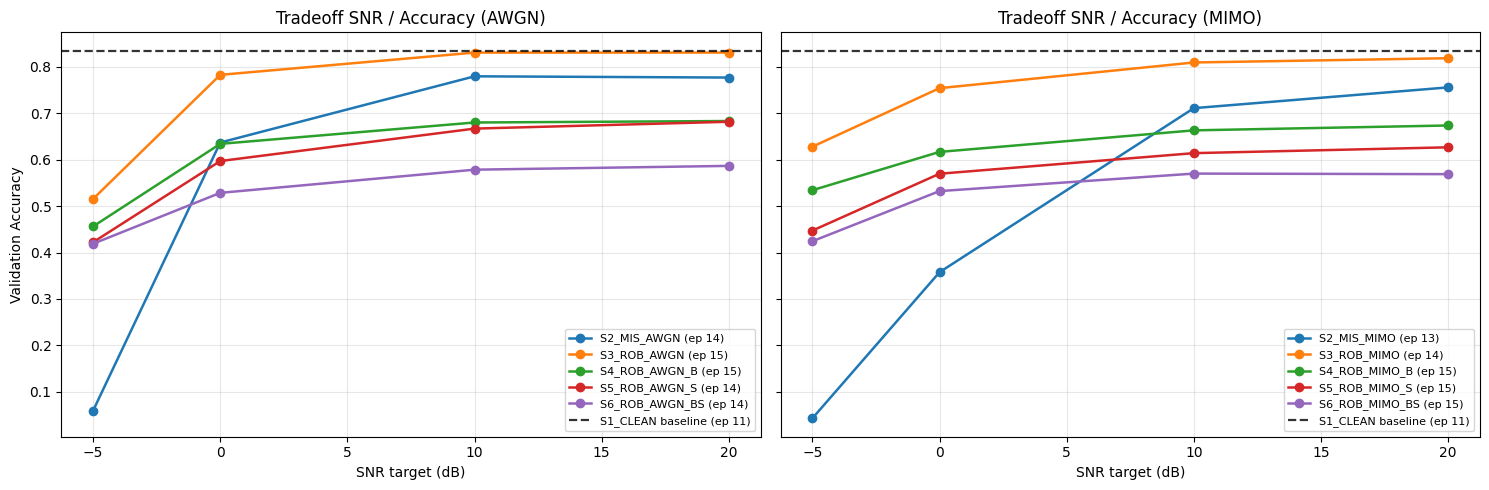

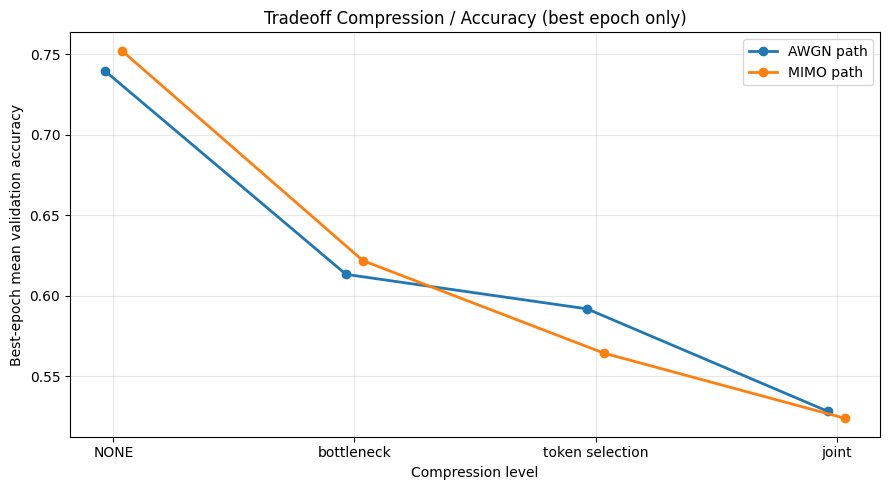

In [7]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# Best-epoch analysis:
# 1) Tradeoff SNR / Accuracy (curve per scenario, usando solo la best epoch)
# 2) Tradeoff Compression / Accuracy (best epoch mean accuracy)
# =====================================================================

run_id = ""  # es. "", "_1", "_2"
snr_to_exclude = {5.0}

SCENARIOS = {
    "S1_CLEAN": {
        "experiments": ["S1_CLEAN"],
        "method": "base",
        "comm": "clean",
    },
    "S2_MIS_AWGN": {
        "experiments": ["S2_MIS_AWGN"],
        "method": "gumbel_eval_channel",
        "comm": "baseline_mimo",
    },
    "S2_MIS_MIMO": {
        "experiments": ["S2_MIS_MIMO"],
        "method": "gumbel_eval_channel",
        "comm": "baseline_mimo_svd",
    },
    "S3_ROB_AWGN": {
        "experiments": ["S3_ROB_AWGN"],
        "method": "base",
        "comm": "baseline_mimo",
    },
    "S3_ROB_MIMO": {
        "experiments": ["S3_ROB_MIMO"],
        "method": "base",
        "comm": "baseline_mimo_svd",
    },
    "S4_ROB_AWGN_B": {
        "experiments": ["S4_ROB_AWGN_B"],
        "method": "base",
        "comm": "baseline_mimo",
    },
    "S4_ROB_MIMO_B": {
        "experiments": ["S4_ROB_MIMO_B"],
        "method": "base",
        "comm": "baseline_mimo_svd",
    },
    "S5_ROB_AWGN_S": {
        "experiments": ["S5_ROB_AWGN_S"],
        "method": "gumbel_eval_channel",
        "comm": "baseline_mimo",
    },
    "S5_ROB_MIMO_S": {
        "experiments": ["S5_ROB_MIMO_S"],
        "method": "gumbel_eval_channel",
        "comm": "baseline_mimo_svd",
    },
    "S6_ROB_AWGN_BS": {
        "experiments": ["S6_ROB_AWGN_BS"],
        "method": "gumbel_eval_channel",
        "comm": "baseline_mimo",
    },
    "S6_ROB_MIMO_BS": {
        "experiments": ["S6_ROB_MIMO_BS"],
        "method": "gumbel_eval_channel",
        "comm": "baseline_mimo_svd",
    },
}

candidate_results_roots = [Path("results"), Path("../results"), Path("../../results")]


def _find_existing_results_root() -> Path:
    for cand in candidate_results_roots:
        if cand.exists():
            return cand
    raise FileNotFoundError("Results root non trovato nelle locazioni candidate.")


def _load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"File non trovato: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


def _resolve_run_folder(results_root: Path, cfg: dict, run_id: str):
    for exp_name in cfg["experiments"]:
        scenario_root = results_root / exp_name

        # Layout flat: JSON direttamente nella cartella scenario
        flat_best = scenario_root / "best_training_results.json"
        flat_final = scenario_root / "final_training_results.json"
        if flat_best.exists() and flat_final.exists():
            return scenario_root

        # Layout nested: scenario/dataset/model/method/comm=...
        method_root = scenario_root / "cifar100" / "deit_tiny_patch16_224.fb_in1k" / cfg["method"]
        nested_folder = method_root / f"comm={cfg['comm']}{run_id}"
        nested_best = nested_folder / "best_training_results.json"
        nested_final = nested_folder / "final_training_results.json"
        if nested_best.exists() and nested_final.exists():
            return nested_folder

    raise FileNotFoundError(
        "Nessun folder risultati valido trovato per scenario: "
        f"experiments={cfg['experiments']}, method={cfg['method']}, comm={cfg['comm']}, run_id={run_id}"
    )


def _extract_best_epoch_info(final_data: dict, snr_to_exclude: set):
    """
    Restituisce:
      - best_epoch_idx (0-based)
      - best_epoch_curve: dict {snr_float: acc_float} per la miglior epoca
      - best_epoch_mean_acc: media accuracy nella miglior epoca
    """
    vals = final_data.get("Val accuracies")
    if not isinstance(vals, list) or len(vals) == 0:
        raise ValueError("Campo 'Val accuracies' assente o vuoto in final_training_results.json")

    # Caso: lista di dict (accuracy per SNR ad ogni epoca)
    if all(isinstance(item, dict) for item in vals):
        epoch_curves = []
        epoch_means = []

        for epoch_dict in vals:
            curve = {}
            for k, v in epoch_dict.items():
                snr = float(k)
                if snr in snr_to_exclude:
                    continue
                curve[snr] = float(v)

            epoch_curves.append(curve)
            if curve:
                epoch_means.append(float(np.mean(list(curve.values()))))
            else:
                epoch_means.append(float("nan"))

        best_epoch_idx = int(np.nanargmax(epoch_means))
        best_epoch_curve = epoch_curves[best_epoch_idx]
        best_epoch_mean_acc = epoch_means[best_epoch_idx]
        return best_epoch_idx, best_epoch_curve, best_epoch_mean_acc

    # Caso clean-like: lista di scalari
    scalar_vals = [float(v) for v in vals]
    best_epoch_idx = int(np.argmax(scalar_vals))
    best_epoch_curve = {}
    best_epoch_mean_acc = scalar_vals[best_epoch_idx]
    return best_epoch_idx, best_epoch_curve, best_epoch_mean_acc


def _scenario_path(name: str) -> str:
    if "_AWGN" in name:
        return "AWGN"
    if "_MIMO" in name:
        return "MIMO"
    return "OTHER"


def _compression_level(name: str) -> str:
    if name.endswith("_BS"):
        return "BS"
    if name.endswith("_B"):
        return "B"
    if name.endswith("_S"):
        return "S"
    return "NONE"


# =====================================================================
# Load + best epoch extraction
# =====================================================================
results_root = _find_existing_results_root()
print(f"Using results root: {results_root.resolve()}")

analysis = {}
for name, cfg in SCENARIOS.items():
    run_folder = _resolve_run_folder(results_root, cfg, run_id)
    final_data = _load_json(run_folder / "final_training_results.json")

    best_epoch_idx, best_epoch_curve, best_epoch_mean_acc = _extract_best_epoch_info(
        final_data, snr_to_exclude
    )

    analysis[name] = {
        "best_epoch": best_epoch_idx + 1,  # 1-based
        "snr_curve": dict(sorted(best_epoch_curve.items())),
        "best_epoch_mean_acc": float(best_epoch_mean_acc),
        "path": _scenario_path(name),
        "compression": _compression_level(name),
    }

print("\nBest epoch per scenario:")
for name in SCENARIOS:
    info = analysis[name]
    print(
        f"- {name}: best_epoch={info['best_epoch']}, "
        f"mean_acc={info['best_epoch_mean_acc']:.4f}, "
        f"path={info['path']}, compression={info['compression']}"
    )


# =====================================================================
# PLOT 1: Tradeoff SNR / Accuracy (best epoch only)
# + baseline clean come riferimento
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
paths_to_plot = ["AWGN", "MIMO"]

clean_baseline = analysis["S1_CLEAN"]["best_epoch_mean_acc"]
clean_ep = analysis["S1_CLEAN"]["best_epoch"]

for ax, path_name in zip(axes, paths_to_plot):
    plotted = 0
    for scenario_name in SCENARIOS.keys():
        info = analysis[scenario_name]
        if info["path"] != path_name:
            continue
        curve = info["snr_curve"]
        if not curve:
            continue

        snrs = list(curve.keys())
        accs = [curve[s] for s in snrs]
        ax.plot(
            snrs,
            accs,
            marker="o",
            linewidth=1.8,
            label=f"{scenario_name} (ep {info['best_epoch']})",
        )
        plotted += 1

    # Baseline orizzontale da S1_CLEAN
    ax.axhline(
        clean_baseline,
        color="black",
        linestyle="--",
        linewidth=1.6,
        alpha=0.8,
        label=f"S1_CLEAN baseline (ep {clean_ep})",
    )

    ax.set_title(f"Tradeoff SNR / Accuracy ({path_name})")
    ax.set_xlabel("SNR target (dB)")
    ax.grid(alpha=0.3)
    if plotted > 0:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)

axes[0].set_ylabel("Validation Accuracy")
plt.tight_layout()
plt.show()


# =====================================================================
# PLOT 2: Tradeoff Compression / Accuracy (best epoch only)
# Nessuna etichetta testuale sui punti, solo linee/marker/legenda
# =====================================================================
compression_order = ["NONE", "B", "S", "BS"]
compression_tick_labels = ["NONE", "bottleneck", "token selection", "joint"]
x_map = {c: i for i, c in enumerate(compression_order)}

paths_for_compression = {
    "AWGN": ["S3_ROB_AWGN", "S4_ROB_AWGN_B", "S5_ROB_AWGN_S", "S6_ROB_AWGN_BS"],
    "MIMO": ["S3_ROB_MIMO", "S4_ROB_MIMO_B", "S5_ROB_MIMO_S", "S6_ROB_MIMO_BS"],
}

path_style = {
    "AWGN": {"x_shift": -0.035},
    "MIMO": {"x_shift": 0.035},
}

plt.figure(figsize=(9, 5))
for path_name, scenario_list in paths_for_compression.items():
    points = []
    for s in scenario_list:
        if s not in analysis:
            continue
        comp = analysis[s]["compression"]
        if comp not in x_map:
            continue
        points.append((x_map[comp], analysis[s]["best_epoch_mean_acc"]))

    points = sorted(points, key=lambda t: t[0])
    if not points:
        continue

    x_shift = path_style[path_name]["x_shift"]
    xs = [p[0] + x_shift for p in points]
    ys = [p[1] for p in points]
    plt.plot(xs, ys, marker="o", linewidth=2.0, label=f"{path_name} path")

plt.xticks(range(len(compression_order)), compression_tick_labels)
plt.xlim(-0.18, len(compression_order) - 1 + 0.18)
plt.xlabel("Compression level")
plt.ylabel("Best-epoch mean validation accuracy")
plt.title("Tradeoff Compression / Accuracy (best epoch only)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

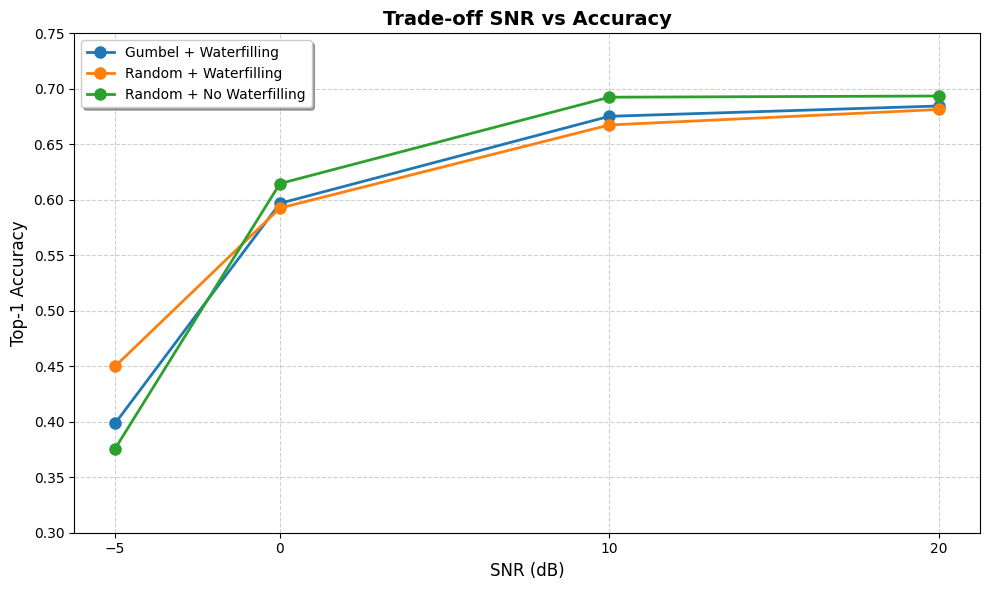

In [13]:
import json
import matplotlib.pyplot as plt
import os

def load_results(path):
    # Cerca il file dei risultati finali
    file_path = os.path.join(path, "final_training_results.json")
    if not os.path.exists(file_path):
        print(f"Saltando {path}: file non trovato.")
        return None, None
    
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # Prendiamo l'ultima entry delle 'Val accuracies' (risultato finale)
    val_accs_list = data.get("Val accuracies", [])
    if not val_accs_list:
        return None, None
    
    last_val = val_accs_list[-1]
    
    # Ordiniamo gli SNR numericamente per il grafico
    snrs = sorted([int(k) for k in last_val.keys()])
    accs = [last_val[str(s)] for s in snrs]
    
    return snrs, accs

# Definizione dei percorsi
results_paths = {
    "Gumbel + Waterfilling": "../results/S5_ROB_AWGN_S/Test_1",
    "Random + Waterfilling": "../results/S5_ROB_AWGN_S_RANDOM/WATERFILLING",
    "Random + No Waterfilling": "../results/S5_ROB_AWGN_S_RANDOM/NO_WATERFILLING"
}

plt.figure(figsize=(10, 6))

for label, path in results_paths.items():
    snrs, accs = load_results(path)
    if snrs is not None:
        plt.plot(snrs, accs, marker='o', label=label, linewidth=2, markersize=8)

# Configurazione del grafico
plt.title("Trade-off SNR vs Accuracy", fontsize=14, fontweight='bold')
plt.xlabel("SNR (dB)", fontsize=12)
plt.ylabel("Top-1 Accuracy", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True, shadow=True)
plt.xticks([-5, 0, 10, 20]) # Basato sui tuoi snr_sweep nel config
plt.ylim(0.3, 0.75) 

# Salvataggio e visualizzazione
plt.tight_layout()
plt.show()


## Change on split point and compression ratio

In [ ]:
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import yaml

# =====================================================================
# Configurazione
# =====================================================================
run_id = ""  # es. "", "_1", "_2"
snr_to_exclude = {5.0}

WORKSPACE_ROOT = Path(r"c:\Users\matteo\OneDrive - uniroma1.it\Documenti\data science\Tesi\proj_locale")
SEARCH_ROOTS = [WORKSPACE_ROOT / "results" / "S_TEST", WORKSPACE_ROOT / "results"]

def _load_json(path: Path) -> dict:
    if not path.exists(): return None
    try: return json.loads(path.read_text(encoding="utf-8"))
    except: return None

def _load_yaml(path: Path) -> dict:
    if not path.exists(): return None
    try:
        with open(path, 'r', encoding="utf-8") as f:
            return yaml.safe_load(f)
    except: return None

def _extract_best_epoch_info(final_data: dict, snr_to_exclude: set):
    vals = final_data.get("Val accuracies")
    if not isinstance(vals, list) or len(vals) == 0: return None, None, None
    if all(isinstance(item, dict) for item in vals):
        epoch_curves, epoch_means = [], []
        for epoch_dict in vals:
            curve = {float(k): float(v) for k, v in epoch_dict.items() if float(k) not in snr_to_exclude}
            epoch_curves.append(curve)
            if curve: epoch_means.append(float(np.mean(list(curve.values()))))
            else: epoch_means.append(float("nan"))
        if not epoch_means or all(np.isnan(epoch_means)): return None, None, None
        best_epoch_idx = int(np.nanargmax(epoch_means))
        return best_epoch_idx, epoch_curves[best_epoch_idx], epoch_means[best_epoch_idx]
    try:
        scalar_vals = [float(v) for v in vals]
        best_epoch_idx = int(np.argmax(scalar_vals))
        return best_epoch_idx, {}, scalar_vals[best_epoch_idx]
    except: return None, None, None

def infer_path(cfg):
    comm_name = cfg.get("communication", {}).get("name", "").lower()
    exp_name = cfg.get("hyperparameters", {}).get("experiment_name", "").upper()
    if "svd" in comm_name or "mimo" in exp_name: return "MIMO"
    return "AWGN"

def get_legend_label(cfg):
    """Genera la label per la legenda basata su metodo e ratio di compressione."""
    method_name = cfg.get("method", {}).get("name", "base")
    params = cfg.get("method", {}).get("parameters", {})
    
    # Identificazione Metodo
    if method_name == "base":
        return "No Compression"
    elif "gumbel" in method_name:
        label = "Gumbel"
    elif "random" in method_name:
        label = "Random"
    else:
        label = method_name
    
    # Estrazione Ratio
    ratio = params.get("desired_compression")
    if ratio is not None:
        return f"{label} ratio {ratio}"
    return label

# =====================================================================
# Logica di Discovery
# =====================================================================
experiments = []
baseline_clean = None
baseline_ep = None

for root in SEARCH_ROOTS:
    if not root.exists(): continue
    for folder in root.iterdir():
        if not folder.is_dir(): continue
        if root.name == "results" and folder.name != "S1_CLEAN": continue
        
        results_files = list(folder.rglob("final_training_results.json"))
        for final_json_path in results_files:
            config_yaml_path = final_json_path.parent / "config.yaml"
            if not config_yaml_path.exists():
                config_yaml_path = final_json_path.parent / ".hydra" / "config.yaml"
            
            data, cfg = _load_json(final_json_path), _load_yaml(config_yaml_path)
            if not data or not cfg: continue
                
            path_type = infer_path(cfg)
            split_index = cfg.get("hyperparameters", {}).get("split_index", "N/A")
            best_idx, best_curve, best_acc = _extract_best_epoch_info(data, snr_to_exclude)
            if best_acc is None: continue
            
            if folder.name == "S1_CLEAN":
                baseline_clean, baseline_ep = best_acc, best_idx + 1
                continue
            
            if path_type == "AWGN":
                experiments.append({
                    "legend_label": get_legend_label(cfg),
                    "split": split_index,
                    "best_epoch": best_idx + 1,
                    "snr_curve": dict(sorted(best_curve.items()))
                })

# =====================================================================
# Plotting
# =====================================================================
splits = sorted(list(set(exp["split"] for exp in experiments if exp["split"] != "N/A")))

if not splits:
    print("Nessun esperimento AWGN valido trovato.")
else:
    for s in splits:
        print(f"\n--- Generazione Grafico SNR/Accuracy per Split Point {s} ---")
        split_exps = [e for e in experiments if e["split"] == s]
        
        plt.figure(figsize=(10, 6))
        
        # Plot Baseline
        if baseline_clean is not None:
            plt.axhline(baseline_clean, color="black", linestyle="--", alpha=0.6, 
                        label=f"Baseline (No Compr.) {baseline_clean:.4f}")
        
        # Plot Esperimenti
        for e in split_exps:
            if e["snr_curve"]:
                curve = e["snr_curve"]
                plt.plot(list(curve.keys()), list(curve.values()), marker="o", linewidth=1.8,
                         label=e["legend_label"])
        
        plt.title(f"SNR vs Accuracy (AWGN Path - Split Point {s})")
        plt.xlabel("SNR target (dB)")
        plt.ylabel("Validation Accuracy")
        plt.grid(alpha=0.3)
        plt.legend(loc='best', fontsize=9)
        plt.tight_layout()
        plt.show()


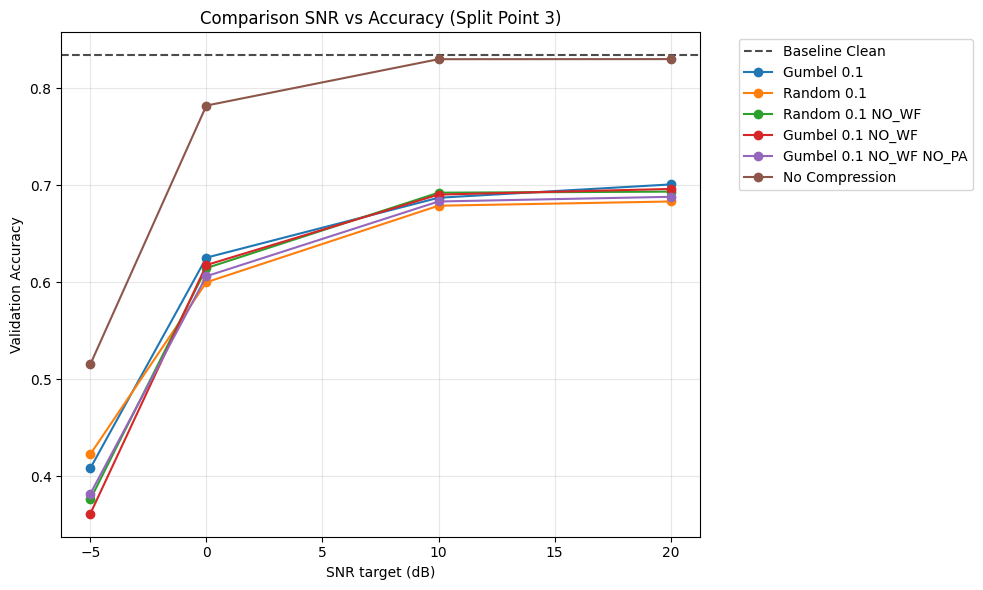

In [11]:
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import yaml

# =====================================================================
# Configurazione
# =====================================================================
run_id = "" 
snr_to_exclude = {5.0} # SNR da escludere se presente
TARGET_SPLIT = 3
TARGET_RATIO = 0.1

WORKSPACE_ROOT = Path(r"c:\Users\matteo\OneDrive - uniroma1.it\Documenti\data science\Tesi\proj_locale")
SEARCH_ROOTS = [WORKSPACE_ROOT / "results" / "S_TEST", WORKSPACE_ROOT / "results"]

def _load_json(path: Path) -> dict:
    if not path.exists(): return None
    try: return json.loads(path.read_text(encoding="utf-8"))
    except: return None

def _load_yaml(path: Path) -> dict:
    if not path.exists(): return None
    try:
        with open(path, 'r', encoding="utf-8") as f:
            return yaml.safe_load(f)
    except: return None

def _extract_best_epoch_info(final_data: dict, snr_to_exclude: set):
    vals = final_data.get("Val accuracies")
    if not isinstance(vals, list) or len(vals) == 0: return None, None, None
    if all(isinstance(item, dict) for item in vals):
        epoch_curves, epoch_means = [], []
        for epoch_dict in vals:
            curve = {float(k): float(v) for k, v in epoch_dict.items() if float(k) not in snr_to_exclude}
            epoch_curves.append(curve)
            if curve: epoch_means.append(float(np.mean(list(curve.values()))))
            else: epoch_means.append(float("nan"))
        if not epoch_means or all(np.isnan(epoch_means)): return None, None, None
        best_epoch_idx = int(np.nanargmax(epoch_means))
        return best_epoch_idx, epoch_curves[best_epoch_idx], epoch_means[best_epoch_idx]
    try:
        scalar_vals = [float(v) for v in vals]
        best_epoch_idx = int(np.argmax(scalar_vals))
        return best_epoch_idx, {}, scalar_vals[best_epoch_idx]
    except: return None, None, None

def get_custom_label(cfg):
    """Genera la label specifica gestendo il caso di parametri nulli."""
    method_name = cfg.get("method", {}).get("name", "base").lower()
    # Protezione contro parametri null
    params = cfg.get("method", {}).get("parameters") or {}
    comm_cfg = cfg.get("communication", {}).get("comm") or {}
    pa_cfg = comm_cfg.get("channel", {}).get("power_alloc") or {}
    
    if method_name == "base":
        return "No Compression"
    
    label = "Gumbel" if "gumbel" in method_name else "Random"
    
    if not pa_cfg.get("enabled", True):
        return f"{label} 0.1 NO_WF NO_PA"
    
    use_wf = params.get("semantic_waterfilling", True)
    if not use_wf or pa_cfg.get("source") != "selection_scores":
        return f"{label} 0.1 NO_WF"
        
    return f"{label} 0.1"

# =====================================================================
# Discovery
# =====================================================================
experiments = []
baseline_clean = None

for root in SEARCH_ROOTS:
    if not root.exists(): continue
    for folder in root.iterdir():
        if not folder.is_dir(): continue
        if root.name == "results" and folder.name != "S1_CLEAN": continue
        
        results_files = list(folder.rglob("final_training_results.json"))
        for final_json_path in results_files:
            config_yaml_path = final_json_path.parent / "config.yaml"
            if not config_yaml_path.exists():
                config_yaml_path = final_json_path.parent / ".hydra" / "config.yaml"
            
            data, cfg = _load_json(final_json_path), _load_yaml(config_yaml_path)
            if not data or not cfg: continue
            
            split = cfg.get("hyperparameters", {}).get("split_index")
            # Protezione params per evitare AttributeError
            params = cfg.get("method", {}).get("parameters") or {}
            ratio = params.get("desired_compression")
            method = cfg.get("method", {}).get("name", "base")
            
            if folder.name == "S1_CLEAN":
                _, _, best_acc = _extract_best_epoch_info(data, snr_to_exclude)
                baseline_clean = best_acc
                continue

            if split == TARGET_SPLIT:
                # Carica se No Compression (base) oppure se il ratio è 0.1
                if method == "base" or (ratio == TARGET_RATIO):
                    best_idx, best_curve, best_acc = _extract_best_epoch_info(data, snr_to_exclude)
                    if best_acc is not None:
                        experiments.append({
                            "label": get_custom_label(cfg),
                            "curve": dict(sorted(best_curve.items())),
                            "best_ep": best_idx + 1
                        })

# =====================================================================
# Plotting
# =====================================================================
plt.figure(figsize=(10, 6))

if baseline_clean:
    plt.axhline(baseline_clean, color="black", linestyle="--", alpha=0.7, label=f"Baseline Clean")

# Ordinamento legenda
order = ["Gumbel 0.1", "Random 0.1", "Random 0.1 NO_WF", "Gumbel 0.1 NO_WF", "Gumbel 0.1 NO_WF NO_PA", "No Compression"]
experiments.sort(key=lambda x: order.index(x["label"]) if x["label"] in order else 99)

for e in experiments:
    if e["curve"]:
        plt.plot(list(e["curve"].keys()), list(e["curve"].values()), marker="o", label=e["label"])

plt.title(f"Comparison SNR vs Accuracy (Split Point {TARGET_SPLIT})")
plt.xlabel("SNR target (dB)")
plt.ylabel("Validation Accuracy")
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## comparison of different compression ratio

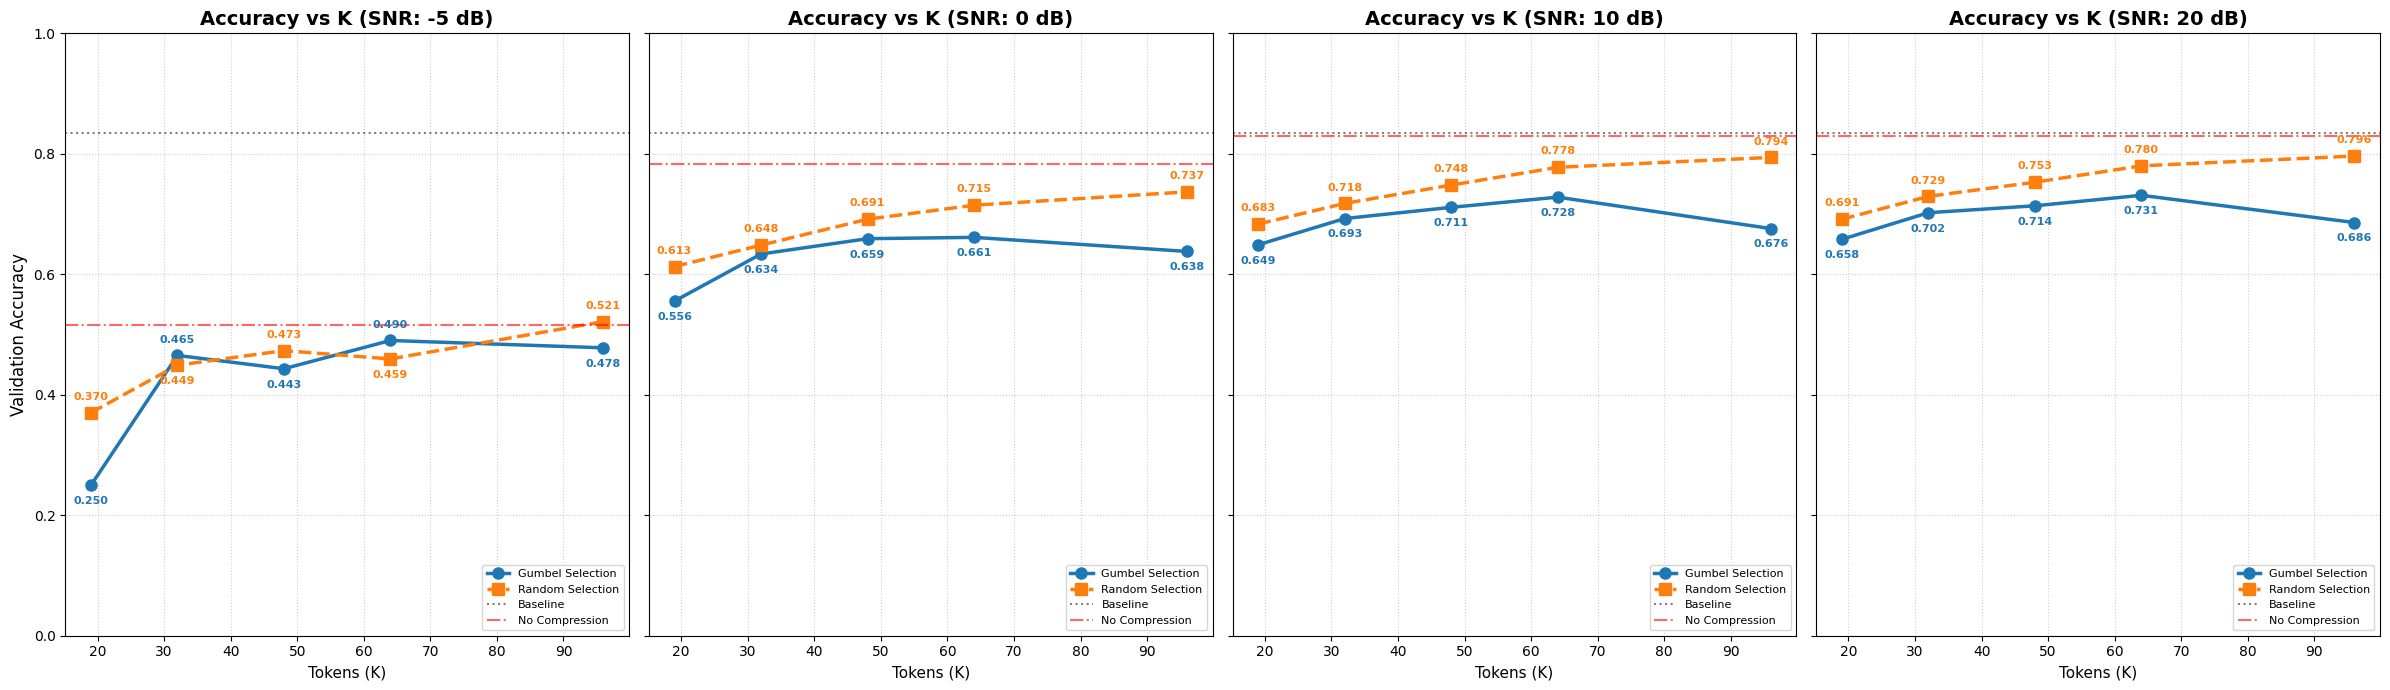

In [13]:
import json
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# =====================================================================
# Configurazione Percorsi
# =====================================================================
WORKSPACE_ROOT = Path(r"c:\Users\matteo\OneDrive - uniroma1.it\Documenti\data science\Tesi\proj_locale")
DATA_ROOTS = {
    "Random": WORKSPACE_ROOT / "results" / "S5_ROB_AWGN_S_RANDOM",
    "Gumbel": WORKSPACE_ROOT / "results" / "S5_ROB_AWGN_S"
}
BASELINE_S3 = WORKSPACE_ROOT / "results" / "S3_ROB_AWGN"
BASELINE_S1 = WORKSPACE_ROOT / "results" / "S1_CLEAN"

def _load_json(path: Path) -> dict:
    if not path.exists(): return None
    try: return json.loads(path.read_text(encoding="utf-8"))
    except: return None

def extract_compression(folder_path: Path):
    match = re.search(r"compression=(\d+)", folder_path.name)
    return int(match.group(1)) if match else None

def get_best_curve(data: dict):
    if not data: return {}
    if "best_val_accuracy" in data:
        curve = data["best_val_accuracy"]
        return {float(k): float(v) for k, v in curve.items()} if isinstance(curve, dict) else {"clean": float(curve)}
    if "Val accuracies" in data:
        vals = data["Val accuracies"]
        if vals and isinstance(vals[0], dict):
            best_curve, max_mean = {}, -1
            for epoch_dict in vals:
                curve = {float(k): float(v) for k, v in epoch_dict.items()}
                mean_acc = np.mean(list(curve.values()))
                if mean_acc > max_mean: max_mean, best_curve = mean_acc, curve
            return best_curve
    return {}

# Discovery Dati
snr_mapping = defaultdict(lambda: defaultdict(list))
data_by_k = defaultdict(lambda: defaultdict(dict))

for method_name, root in DATA_ROOTS.items():
    if not root.exists(): continue
    for folder in root.iterdir():
        if not folder.is_dir(): continue
        comp_val = extract_compression(folder)
        if comp_val is None: continue
        file = folder / "best_training_results.json"
        if not file.exists(): file = folder / "final_training_results.json"
        curve = get_best_curve(_load_json(file))
        for snr, acc in curve.items():
            if snr != "clean":
                snr_mapping[snr][method_name].append((comp_val, acc))
                data_by_k[snr][comp_val][method_name] = acc

s3_data = get_best_curve(_load_json(BASELINE_S3 / "best_training_results.json"))
s1_val = _load_json(BASELINE_S1 / "best_training_results.json").get("best_val_accuracy")

# =====================================================================
# Plotting (4 Grafici in Fila Orizzontale)
# =====================================================================
sorted_snrs = sorted(snr_mapping.keys())
n_snrs = len(sorted_snrs)

# Creiamo la griglia: 1 riga, 4 colonne (o n_snrs se diverso da 4)
fig, axes = plt.subplots(1, n_snrs, figsize=(6 * n_snrs, 7), sharey=True)

# Se c'è solo un SNR, axes non è una lista, lo rendiamo tale
if n_snrs == 1: axes = [axes]

colors = {"Gumbel": "tab:blue", "Random": "tab:orange"}
styles = {"Gumbel": "-o", "Random": "--s"}
offset = 0.018

for i, snr in enumerate(sorted_snrs):
    ax = axes[i]
    
    # --- Metodi con Compressione ---
    for method in ["Gumbel", "Random"]:
        points = snr_mapping[snr][method]
        if points:
            points.sort()
            x, y = zip(*points)
            ax.plot(x, y, styles[method], label=f"{method} Selection", 
                    linewidth=2.5, markersize=8, color=colors[method])

    # --- Logica Dinamica Etichette ---
    for k in sorted(data_by_k[snr].keys()):
        methods_at_k = data_by_k[snr][k]
        if len(methods_at_k) == 2:
            g_acc, r_acc = methods_at_k["Gumbel"], methods_at_k["Random"]
            if g_acc > r_acc:
                ax.text(k, g_acc + offset, f"{g_acc:.3f}", ha='center', va='bottom', color=colors["Gumbel"], fontweight='bold', fontsize=8)
                ax.text(k, r_acc - offset, f"{r_acc:.3f}", ha='center', va='top', color=colors["Random"], fontweight='bold', fontsize=8)
            else:
                ax.text(k, r_acc + offset, f"{r_acc:.3f}", ha='center', va='bottom', color=colors["Random"], fontweight='bold', fontsize=8)
                ax.text(k, g_acc - offset, f"{g_acc:.3f}", ha='center', va='top', color=colors["Gumbel"], fontweight='bold', fontsize=8)
        else:
            for method, acc in methods_at_k.items():
                ax.text(k, acc + offset, f"{acc:.3f}", ha='center', va='bottom', color=colors[method], fontweight='bold', fontsize=8)

    # --- Baseline & No Compression ---
    if s1_val: ax.axhline(y=s1_val, color='black', linestyle=':', alpha=0.5, label="Baseline")
    if snr in s3_data: ax.axhline(y=s3_data[snr], color='red', linestyle='-.', alpha=0.6, label="No Compression")

    snr_label = int(snr) if snr == int(snr) else snr
    ax.set_title(f"Accuracy vs K (SNR: {snr_label} dB)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Tokens (K)", fontsize=11)
    if i == 0: ax.set_ylabel("Validation Accuracy", fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()
